# Adaptive KV-Cache Compression Evaluation

Loads the three saved LightGBM payloads, recreates the held-out test set, evaluates all 16 latency–memory constraint pairs, and produces dataset-specific performance graphs plus selection and violation analyses.

**Expected model folder:** `MyDrive/KV_Cache_Models/`


## 1. Mount Google Drive and import packages


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import ast
import io
import re
from itertools import product
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from sklearn.model_selection import train_test_split


Mounted at /content/drive


## 2. Configuration


In [ ]:
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
RS = 42
TEST_FRAC = 0.15
PERCENTILES = [25, 50, 75, 90]

MODEL_DIR = Path("/content/drive/MyDrive/KV_Cache_Models")
OUTPUT_DIR = MODEL_DIR / "adaptive_evaluation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIGS = [
    "kvquant_2bit", "kvquant_3bit", "kvquant_4bit",
    "h2o_20", "h2o_40", "h2o_60",
    "rocketkv_8x", "rocketkv_16x", "rocketkv_32x",
]

# Highest-quality eligible setting is listed first within each family.
FAMILY_PRIORITY = {
    "KVQuant": ["kvquant_4bit", "kvquant_3bit", "kvquant_2bit"],
    "H2O": ["h2o_60", "h2o_40", "h2o_20"],
    "RocketKV": ["rocketkv_8x", "rocketkv_16x", "rocketkv_32x"],
}

FNAME = {
    "kvquant_2bit": "kvquant_2bit",
    "kvquant_3bit": "kvquant_3bit",
    "kvquant_4bit": "kvquant_4bit",
    "h2o_20": "h2o_budget_20pct",
    "h2o_40": "h2o_budget_40pct",
    "h2o_60": "h2o_budget_60pct",
    "rocketkv_8x": "rocketkv_ratio_8x",
    "rocketkv_16x": "rocketkv_ratio_16x",
    "rocketkv_32x": "rocketkv_ratio_32x",
}

DATASETS = ["gsm8k", "arc_challenge", "hellaswag"]
DATASET_TITLES = {
    "gsm8k": "GSM8K",
    "arc_challenge": "ARC Challenge",
    "hellaswag": "HellaSwag",
}
IS_MCQ = {"gsm8k": False, "arc_challenge": True, "hellaswag": True}
REPO_RAW = "https://raw.githubusercontent.com/yoshikodes/KVCacheCompression/main/Data"


## 3. Reconstruct prompts and load measured data


In [ ]:
# ---------------------------------------------------------------------------
# Exact prompt reconstruction used during training
# ---------------------------------------------------------------------------
GSM8K_FEWSHOT_PREFIX = """You are solving grade-school math word problems.
Show the calculation step by step, then end with exactly this format:
#### <final number>

Question: There are 15 trees in the grove. Grove workers will plant trees today. After they are done, there will be 21 trees. How many trees did the grove workers plant today?
Answer: There are 15 trees originally. After planting, there are 21 trees. So the workers planted 21 - 15 = 6 trees.
#### 6

Question: If there are 3 cars in the parking lot and 2 more cars arrive, how many cars are in the parking lot?
Answer: There are originally 3 cars. 2 more cars arrive. 3 + 2 = 5 cars.
#### 5

Question: Leah had 32 chocolates and her sister had 42. If they ate 35, how many pieces do they have left in total?
Answer: Leah and her sister started with 32 + 42 = 74 chocolates. After eating 35, they have 74 - 35 = 39 left.
#### 39

Question: Jason had 20 lollipops. He gave Denny some lollipops. Now Jason has 12 lollipops. How many lollipops did Jason give to Denny?
Answer: Jason started with 20 lollipops and now has 12. So he gave away 20 - 12 = 8 lollipops.
#### 8

Question: Shawn has five toys. For Christmas, he got two toys each from his mom and dad. How many toys does he have now?
Answer: Shawn started with 5 toys. He got 2 from mom and 2 from dad, which is 2 + 2 = 4 more toys. 5 + 4 = 9 toys total.
#### 9

Question: There were nine computers in the server room. Five more computers were installed each day, from Monday to Thursday. How many computers are now in the server room?
Answer: 4 days from Monday to Thursday, with 5 computers installed each day, is 4 * 5 = 20 computers added. 9 + 20 = 29 computers total.
#### 29

Question: Michael had 58 golf balls. On Tuesday, he lost 23 golf balls. On Wednesday, he lost 2 more. How many golf balls did he have at the end of Wednesday?
Answer: Michael started with 58 golf balls. After losing 23 on Tuesday, he had 58 - 23 = 35. After losing 2 more on Wednesday, he had 35 - 2 = 33 golf balls.
#### 33

Question: Olivia has $23. She bought five bagels for $3 each. How much money does she have left?
Answer: Five bagels at $3 each cost 5 * 3 = 15 dollars. Olivia started with $23, so she has 23 - 15 = 8 dollars left.
#### 8
"""
GSM8K_Q_LEAD = "\nQuestion: "
GSM8K_A_TAIL = "\nAnswer:"
CHOICES_BLOCK_HEADER = "\n\nAnswer choices:\n"


def format_choices_block(choices):
    lines = []
    for i, entry in enumerate(choices):
        if isinstance(entry, (list, tuple)) and len(entry) == 2:
            label, text = entry
        else:
            label, text = chr(ord("A") + i), entry
        lines.append(f"{label}. {text}")
    return CHOICES_BLOCK_HEADER + "\n".join(lines)


def patch_gsm8k(prompt):
    prompt = str(prompt)
    if prompt.startswith(GSM8K_FEWSHOT_PREFIX):
        return prompt
    return GSM8K_FEWSHOT_PREFIX + GSM8K_Q_LEAD + prompt + GSM8K_A_TAIL


def patch_mc(prompt, choices_cell):
    prompt = str(prompt)
    if CHOICES_BLOCK_HEADER in prompt:
        return prompt
    try:
        choices = ast.literal_eval(choices_cell)
    except (ValueError, SyntaxError):
        return prompt
    return prompt + format_choices_block(choices)


def read_result(config, dataset):
    filename = f"{FNAME[config]}_{dataset}_per_prompt.csv"
    response = requests.get(f"{REPO_RAW}/{filename}", timeout=60)
    response.raise_for_status()
    frame = pd.read_csv(io.StringIO(response.text))
    index_col = "question_index" if "question_index" in frame.columns else "item_index"
    return frame.rename(columns={index_col: "idx"})


def build_wide(target):
    """One row per prompt and one target column per compression method."""
    frames = []
    for dataset in DATASETS:
        reference = read_result("kvquant_2bit", dataset)
        columns = ["idx", "prompt"] + (["choices"] if IS_MCQ[dataset] else [])
        reference = reference[columns]
        if IS_MCQ[dataset]:
            model_input = [
                patch_mc(prompt, choices)
                for prompt, choices in zip(reference["prompt"], reference["choices"])
            ]
        else:
            model_input = [patch_gsm8k(prompt) for prompt in reference["prompt"]]

        base = pd.DataFrame({
            "dataset": dataset,
            "idx": reference["idx"].values,
            "model_input": model_input,
        })
        for config in CONFIGS:
            values = read_result(config, dataset)[["idx", target]].rename(
                columns={target: config}
            )
            base = base.merge(values, on="idx", how="inner", validate="one_to_one")
        frames.append(base)

    wide = pd.concat(frames, ignore_index=True)
    assert not wide[CONFIGS].isna().any().any()
    return wide


## 4. Feature engineering and prediction helpers


In [ ]:
# ---------------------------------------------------------------------------
# Exact feature engineering used during training
# ---------------------------------------------------------------------------
def prompt_features(prompt):
    text = str(prompt)
    tokens = text.split()
    token_count = max(len(tokens), 1)
    char_count = max(len(text), 1)
    return {
        "n_char": len(text),
        "n_tok": len(tokens),
        "ttr": len(set(tokens)) / token_count,
        "digit_ratio": sum(c.isdigit() for c in text) / char_count,
        "punct_ratio": sum(not c.isalnum() and not c.isspace() for c in text) / char_count,
        "upper_ratio": sum(c.isupper() for c in text) / char_count,
        "avg_tok": char_count / token_count,
        "num_count": len(re.findall(r"\d+", text)),
        "has_q": int("?" in text),
        "n_newline": text.count("\n"),
    }


DS_DUMMY_COLS = [f"ds_{dataset}" for dataset in DATASETS]


def feature_matrix(frame, feature_cols):
    features = pd.DataFrame([prompt_features(p) for p in frame["model_input"]])
    dummies = pd.get_dummies(frame["dataset"], prefix="ds").reindex(
        columns=DS_DUMMY_COLS, fill_value=0
    )
    matrix = pd.concat(
        [features.reset_index(drop=True), dummies.reset_index(drop=True)], axis=1
    )
    # Keep labels to avoid repeated sklearn feature-name warnings.
    return matrix.reindex(columns=feature_cols, fill_value=0)


def regression_predictions(payload, x):
    raw = np.column_stack([model.predict(x) for model in payload["models"]])
    if payload.get("target_space") == "log1p":
        raw = np.expm1(raw)
    return raw[0]


def correctness_predictions(payload, x):
    probabilities = []
    for kind, model in payload["models"]:
        if kind == "const":
            probabilities.append(float(model))
        else:
            probabilities.append(float(model.predict_proba(x)[0, 1]))
    return np.asarray(probabilities)


def select_highest_quality_per_family(eligible):
    selected = []
    eligible = set(eligible)
    for priority in FAMILY_PRIORITY.values():
        choice = next((method for method in priority if method in eligible), None)
        if choice is not None:
            selected.append(choice)
    return selected


def smallest_combined_violation(pred_latency, pred_memory, latency_limit, memory_limit):
    """Minimize sum of relative excess; zero means a constraint is satisfied."""
    latency_excess = np.maximum(pred_latency / latency_limit - 1.0, 0.0)
    memory_excess = np.maximum(pred_memory / memory_limit - 1.0, 0.0)
    return latency_excess + memory_excess


## 5. Load models and reproduce the split


In [ ]:
# ---------------------------------------------------------------------------
# Load models and reconstruct the identical train/test split
# ---------------------------------------------------------------------------
latency_model = joblib.load(MODEL_DIR / "reg_total_latency_lightgbm.joblib")
memory_model = joblib.load(MODEL_DIR / "reg_peak_memory_lightgbm.joblib")
correct_model = joblib.load(MODEL_DIR / "clf_correct_lightgbm.joblib")

for payload in (latency_model, memory_model, correct_model):
    assert payload["configs"] == CONFIGS, "Unexpected compression-method ordering"

print("Loading measured per-prompt data...")
latency_wide = build_wide("total_latency_sec")
memory_wide = build_wide("peak_memory_gb")
correct_wide = build_wide("correct")

# Verify that all metrics contain exactly the same prompt keys.
key_cols = ["dataset", "idx"]
latency_keys = set(map(tuple, latency_wide[key_cols].to_numpy()))
assert latency_keys == set(map(tuple, memory_wide[key_cols].to_numpy()))
assert latency_keys == set(map(tuple, correct_wide[key_cols].to_numpy()))

# The training notebooks split each dataset separately using these exact values.
train_parts, test_parts = [], []
for dataset, group in latency_wide.groupby("dataset"):
    train_part, test_part = train_test_split(
        group, test_size=TEST_FRAC, random_state=RS, shuffle=True
    )
    train_parts.append(train_part)
    test_parts.append(test_part)

train_df = pd.concat(train_parts).sample(frac=1, random_state=RS).reset_index(drop=True)
test_df = pd.concat(test_parts).sample(frac=1, random_state=RS).reset_index(drop=True)

memory_lookup = memory_wide.set_index(key_cols)[CONFIGS]
correct_lookup = correct_wide.set_index(key_cols)[CONFIGS]
latency_lookup = latency_wide.set_index(key_cols)[CONFIGS]


Loading measured per-prompt data...


## 6. Calculate training-only percentile thresholds


In [ ]:
# ---------------------------------------------------------------------------
# Percentile thresholds use measured TRAINING data only, across all 9 methods.
# ---------------------------------------------------------------------------
latency_percentiles = dict(zip(
    PERCENTILES,
    np.percentile(train_df[CONFIGS].to_numpy(dtype=float).ravel(), PERCENTILES),
))

train_keys = pd.MultiIndex.from_frame(train_df[key_cols])
training_memory_values = memory_lookup.loc[train_keys].to_numpy(dtype=float).ravel()
memory_percentiles = dict(zip(
    PERCENTILES,
    np.percentile(training_memory_values, PERCENTILES),
))

percentile_table = pd.DataFrame({
    "percentile": PERCENTILES,
    "latency_threshold_sec": [latency_percentiles[p] for p in PERCENTILES],
    "memory_threshold_gb": [memory_percentiles[p] for p in PERCENTILES],
})
percentile_table.to_csv(OUTPUT_DIR / "training_percentiles.csv", index=False)
print("\nTraining-only thresholds:")
print(percentile_table.to_string(index=False))



Training-only thresholds:
 percentile  latency_threshold_sec  memory_threshold_gb
         25               3.865812             0.002287
         50               8.315173             0.006226
         75              17.327303             0.029915
         90              26.187829             0.082642


## 7. Run all 16 constraint combinations


In [ ]:
# ---------------------------------------------------------------------------
# Adaptive evaluation: 16 threshold pairs x every held-out prompt.
# Predictions deliberately occur inside the prompt loop, as requested.
# ---------------------------------------------------------------------------
records = []

for latency_pct, memory_pct in product(PERCENTILES, PERCENTILES):
    latency_limit = latency_percentiles[latency_pct]
    memory_limit = memory_percentiles[memory_pct]
    print(f"Evaluating L{latency_pct}/M{memory_pct}...")

    for _, prompt_row in test_df.iterrows():
        one_prompt = prompt_row.to_frame().T
        x_latency = feature_matrix(one_prompt, latency_model["feature_cols"])
        x_memory = feature_matrix(one_prompt, memory_model["feature_cols"])
        x_correct = feature_matrix(one_prompt, correct_model["feature_cols"])

        pred_latency = regression_predictions(latency_model, x_latency)
        pred_memory = regression_predictions(memory_model, x_memory)
        pred_correct = correctness_predictions(correct_model, x_correct)

        eligible_indices = np.flatnonzero(
            (pred_latency <= latency_limit) & (pred_memory <= memory_limit)
        )
        eligible_methods = [CONFIGS[i] for i in eligible_indices]

        if eligible_methods:
            family_candidates = select_highest_quality_per_family(eligible_methods)
            candidate_indices = [CONFIGS.index(method) for method in family_candidates]
            chosen_index = max(candidate_indices, key=lambda i: pred_correct[i])
            used_fallback = False
        else:
            # No feasible method: minimize normalized combined constraint excess.
            violation_scores = smallest_combined_violation(
                pred_latency, pred_memory, latency_limit, memory_limit
            )
            best_score = violation_scores.min()
            tied = np.flatnonzero(np.isclose(violation_scores, best_score))
            # Correctness probability breaks exact violation-score ties.
            chosen_index = max(tied, key=lambda i: pred_correct[i])
            family_candidates = []
            used_fallback = True

        chosen_method = CONFIGS[chosen_index]
        key = (prompt_row["dataset"], prompt_row["idx"])
        actual_latency = float(latency_lookup.loc[key, chosen_method])
        actual_memory = float(memory_lookup.loc[key, chosen_method])
        actual_correct = int(correct_lookup.loc[key, chosen_method])

        records.append({
            "latency_percentile": latency_pct,
            "memory_percentile": memory_pct,
            "constraint_label": f"L{latency_pct}/M{memory_pct}",
            "latency_threshold_sec": latency_limit,
            "memory_threshold_gb": memory_limit,
            "dataset": prompt_row["dataset"],
            "idx": prompt_row["idx"],
            "selected_method": chosen_method,
            "eligible_count": len(eligible_methods),
            "family_candidate_count": len(family_candidates),
            "used_fallback": used_fallback,
            "predicted_latency_sec": float(pred_latency[chosen_index]),
            "predicted_memory_gb": float(pred_memory[chosen_index]),
            "predicted_correct_probability": float(pred_correct[chosen_index]),
            "actual_latency_sec": actual_latency,
            "actual_memory_gb": actual_memory,
            "actual_correct": actual_correct,
            "latency_violation": actual_latency > latency_limit,
            "memory_violation": actual_memory > memory_limit,
            "any_violation": (actual_latency > latency_limit) or (actual_memory > memory_limit),
        })

adaptive_results = pd.DataFrame(records)
adaptive_results.to_csv(OUTPUT_DIR / "adaptive_prompt_results.csv", index=False)


Evaluating L25/M25...
Evaluating L25/M50...
Evaluating L25/M75...
Evaluating L25/M90...
Evaluating L50/M25...
Evaluating L50/M50...
Evaluating L50/M75...
Evaluating L50/M90...
Evaluating L75/M25...
Evaluating L75/M50...
Evaluating L75/M75...
Evaluating L75/M90...
Evaluating L90/M25...
Evaluating L90/M50...
Evaluating L90/M75...
Evaluating L90/M90...


## 8. Compare methods separately for each dataset


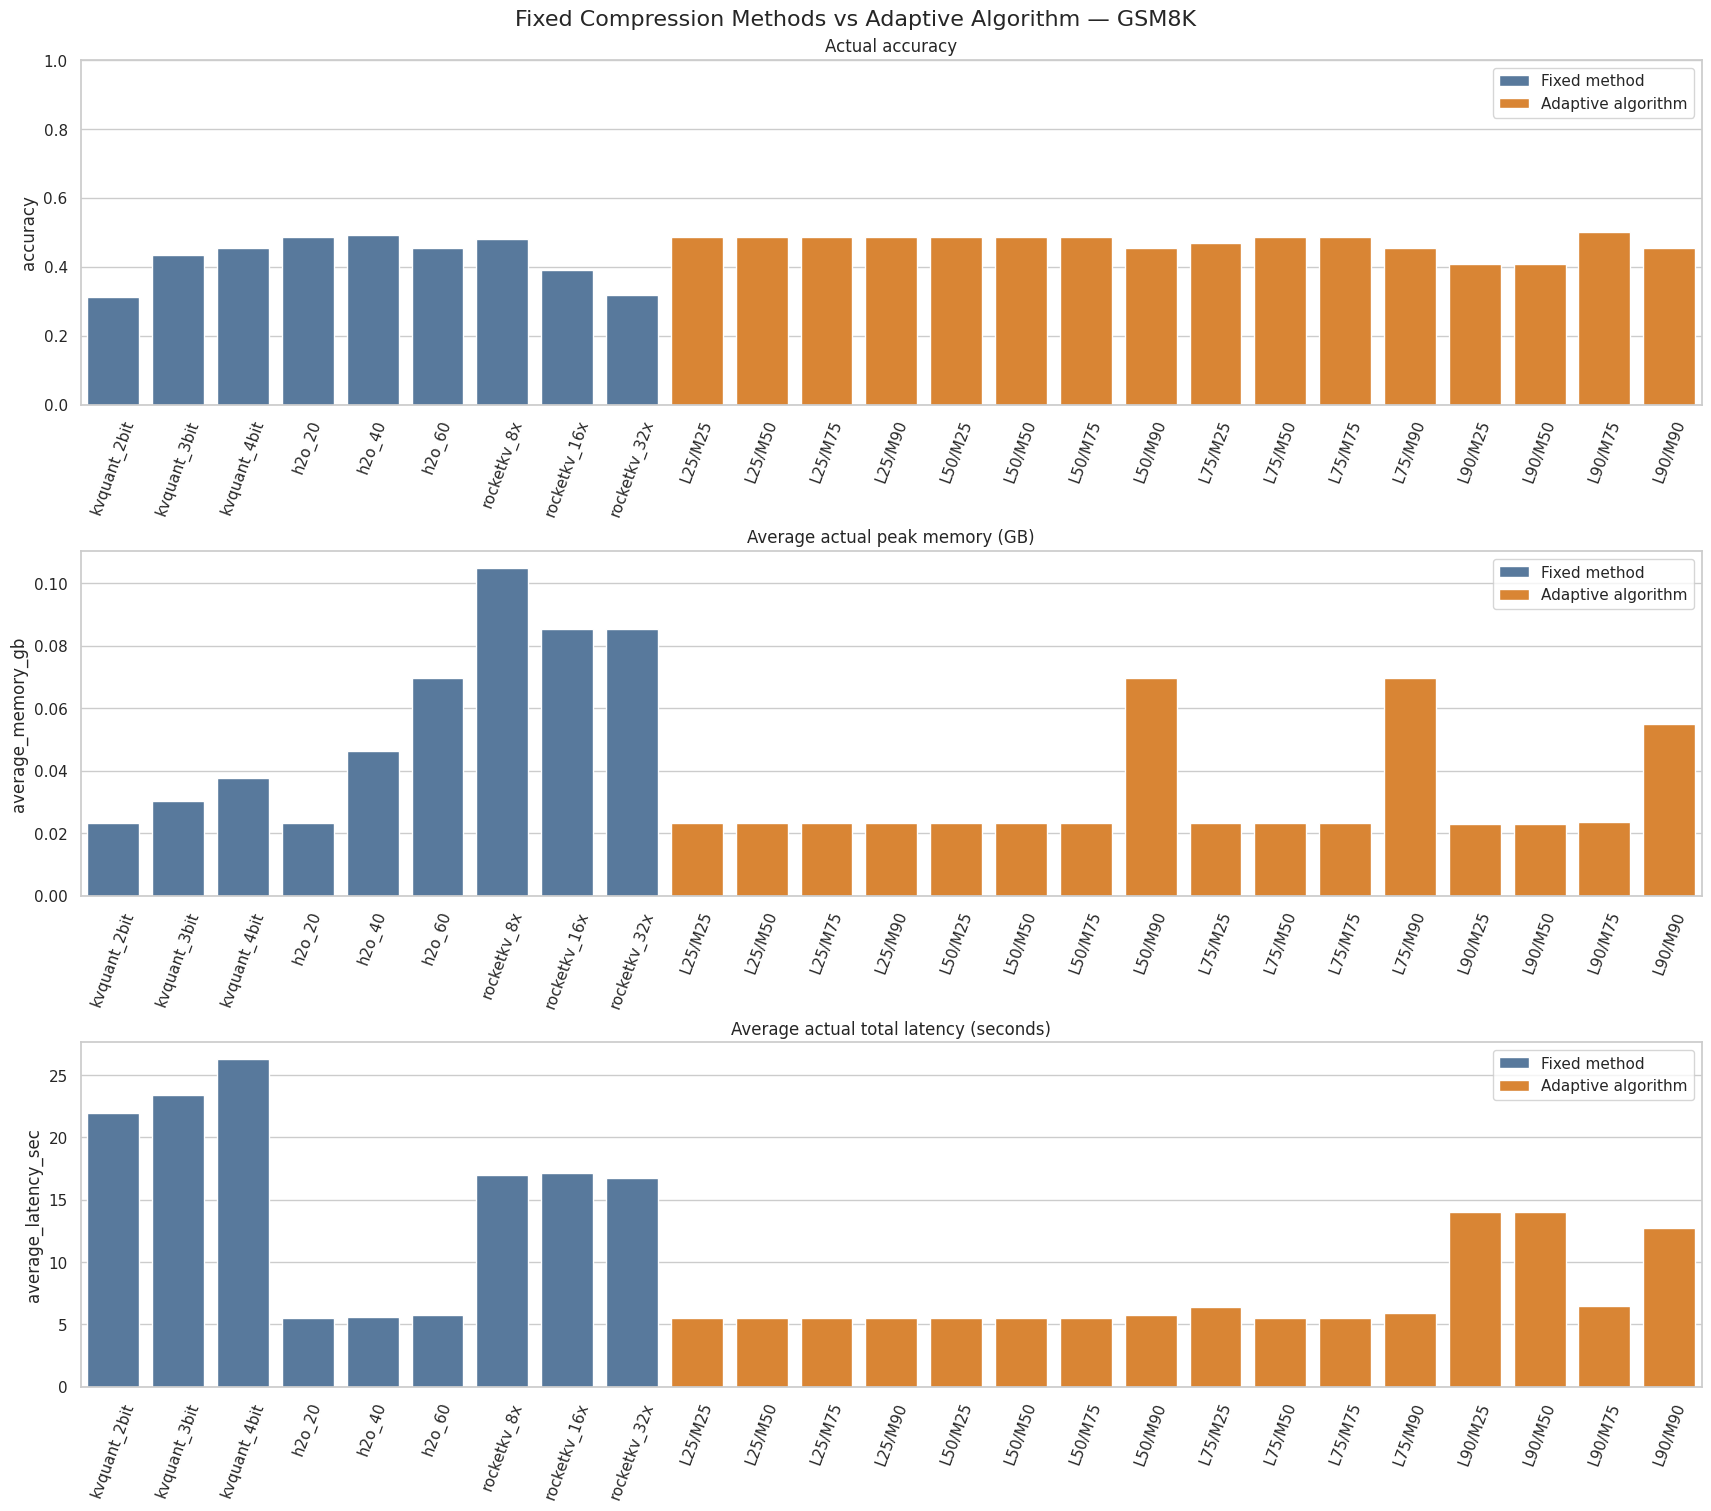

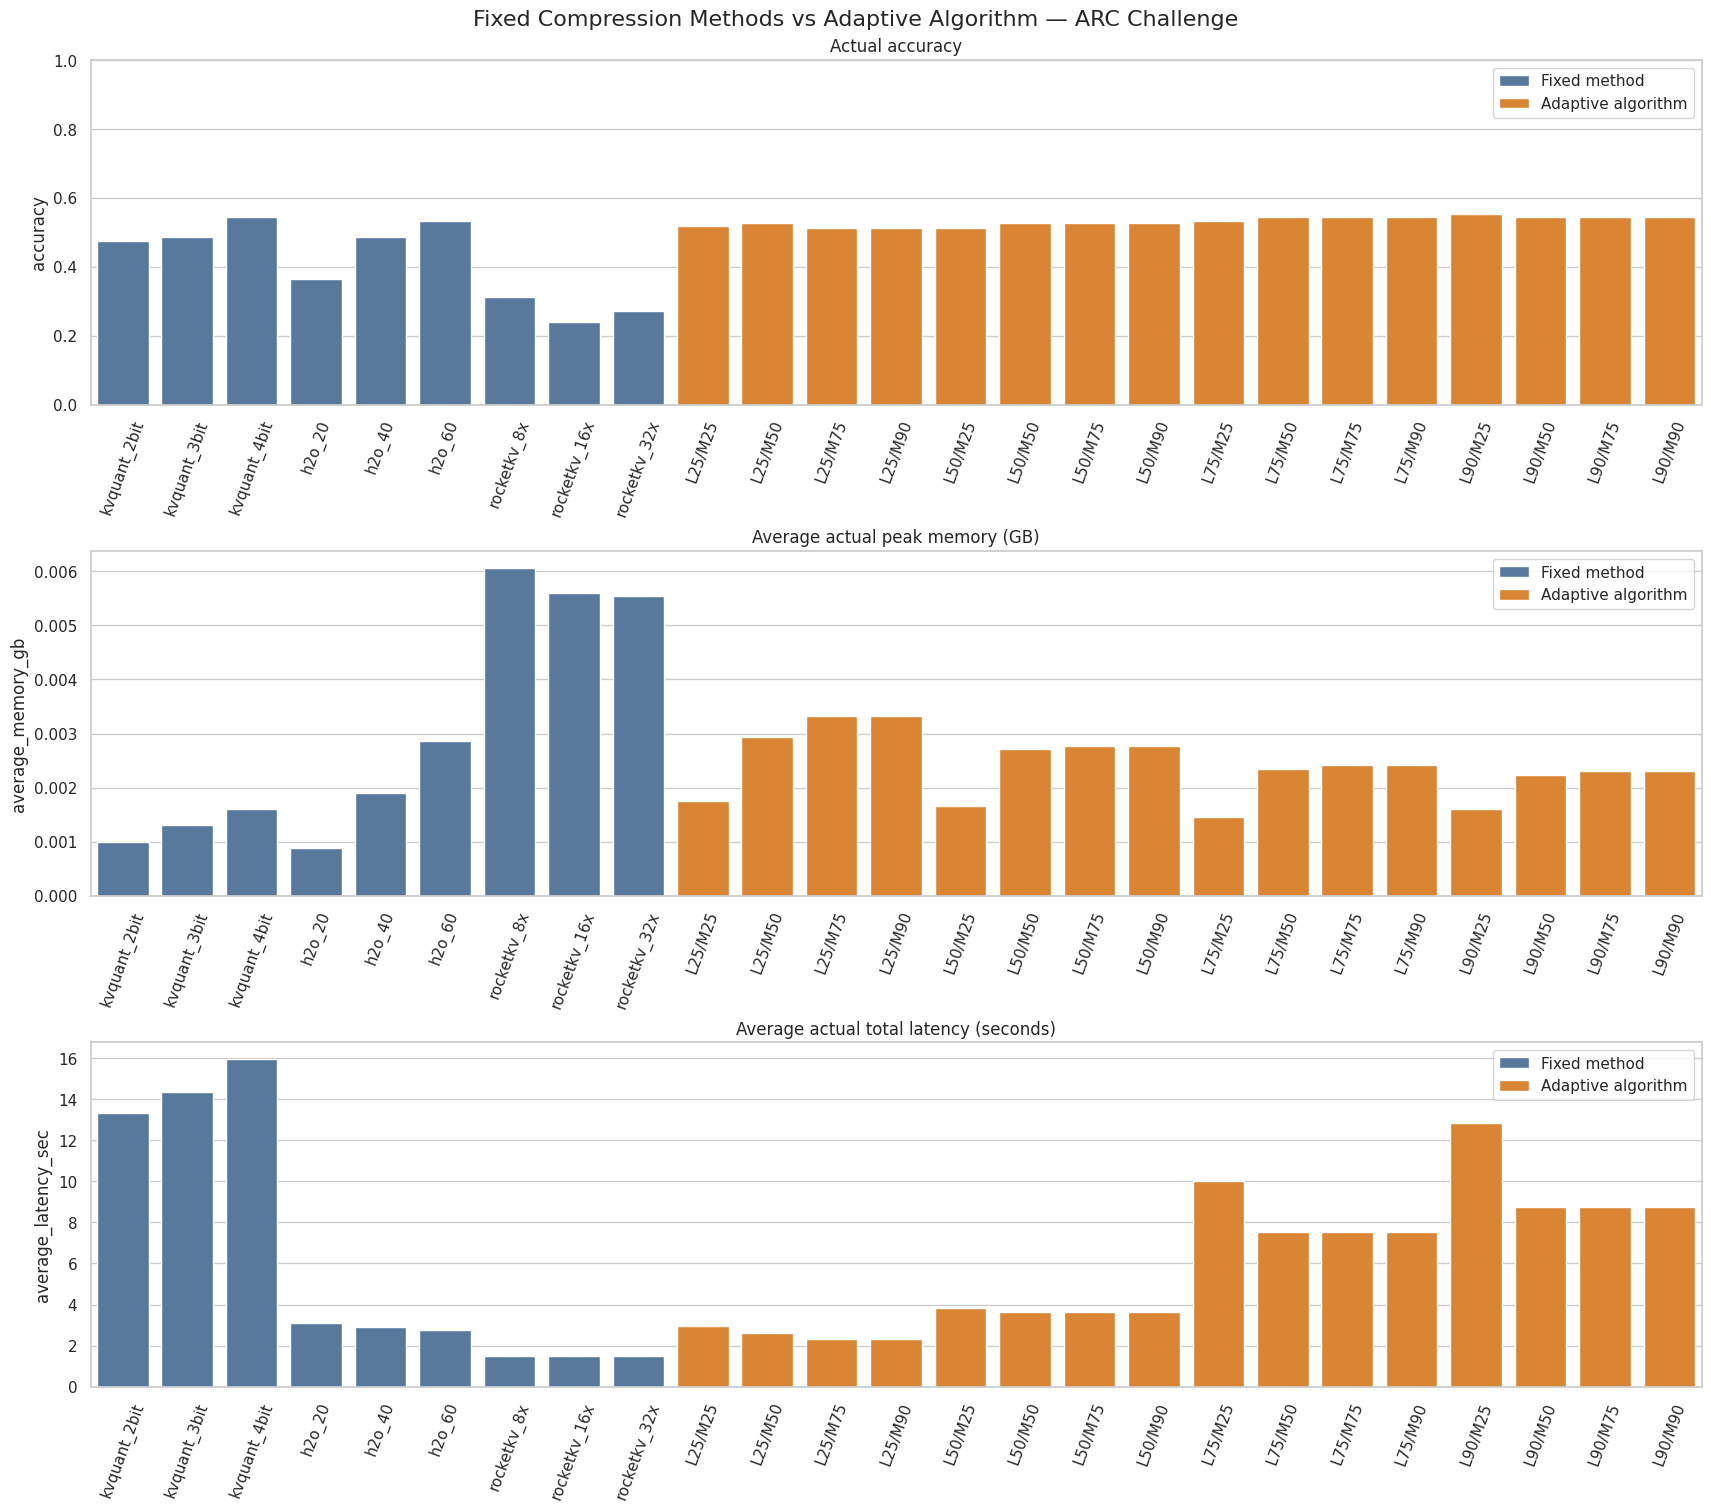

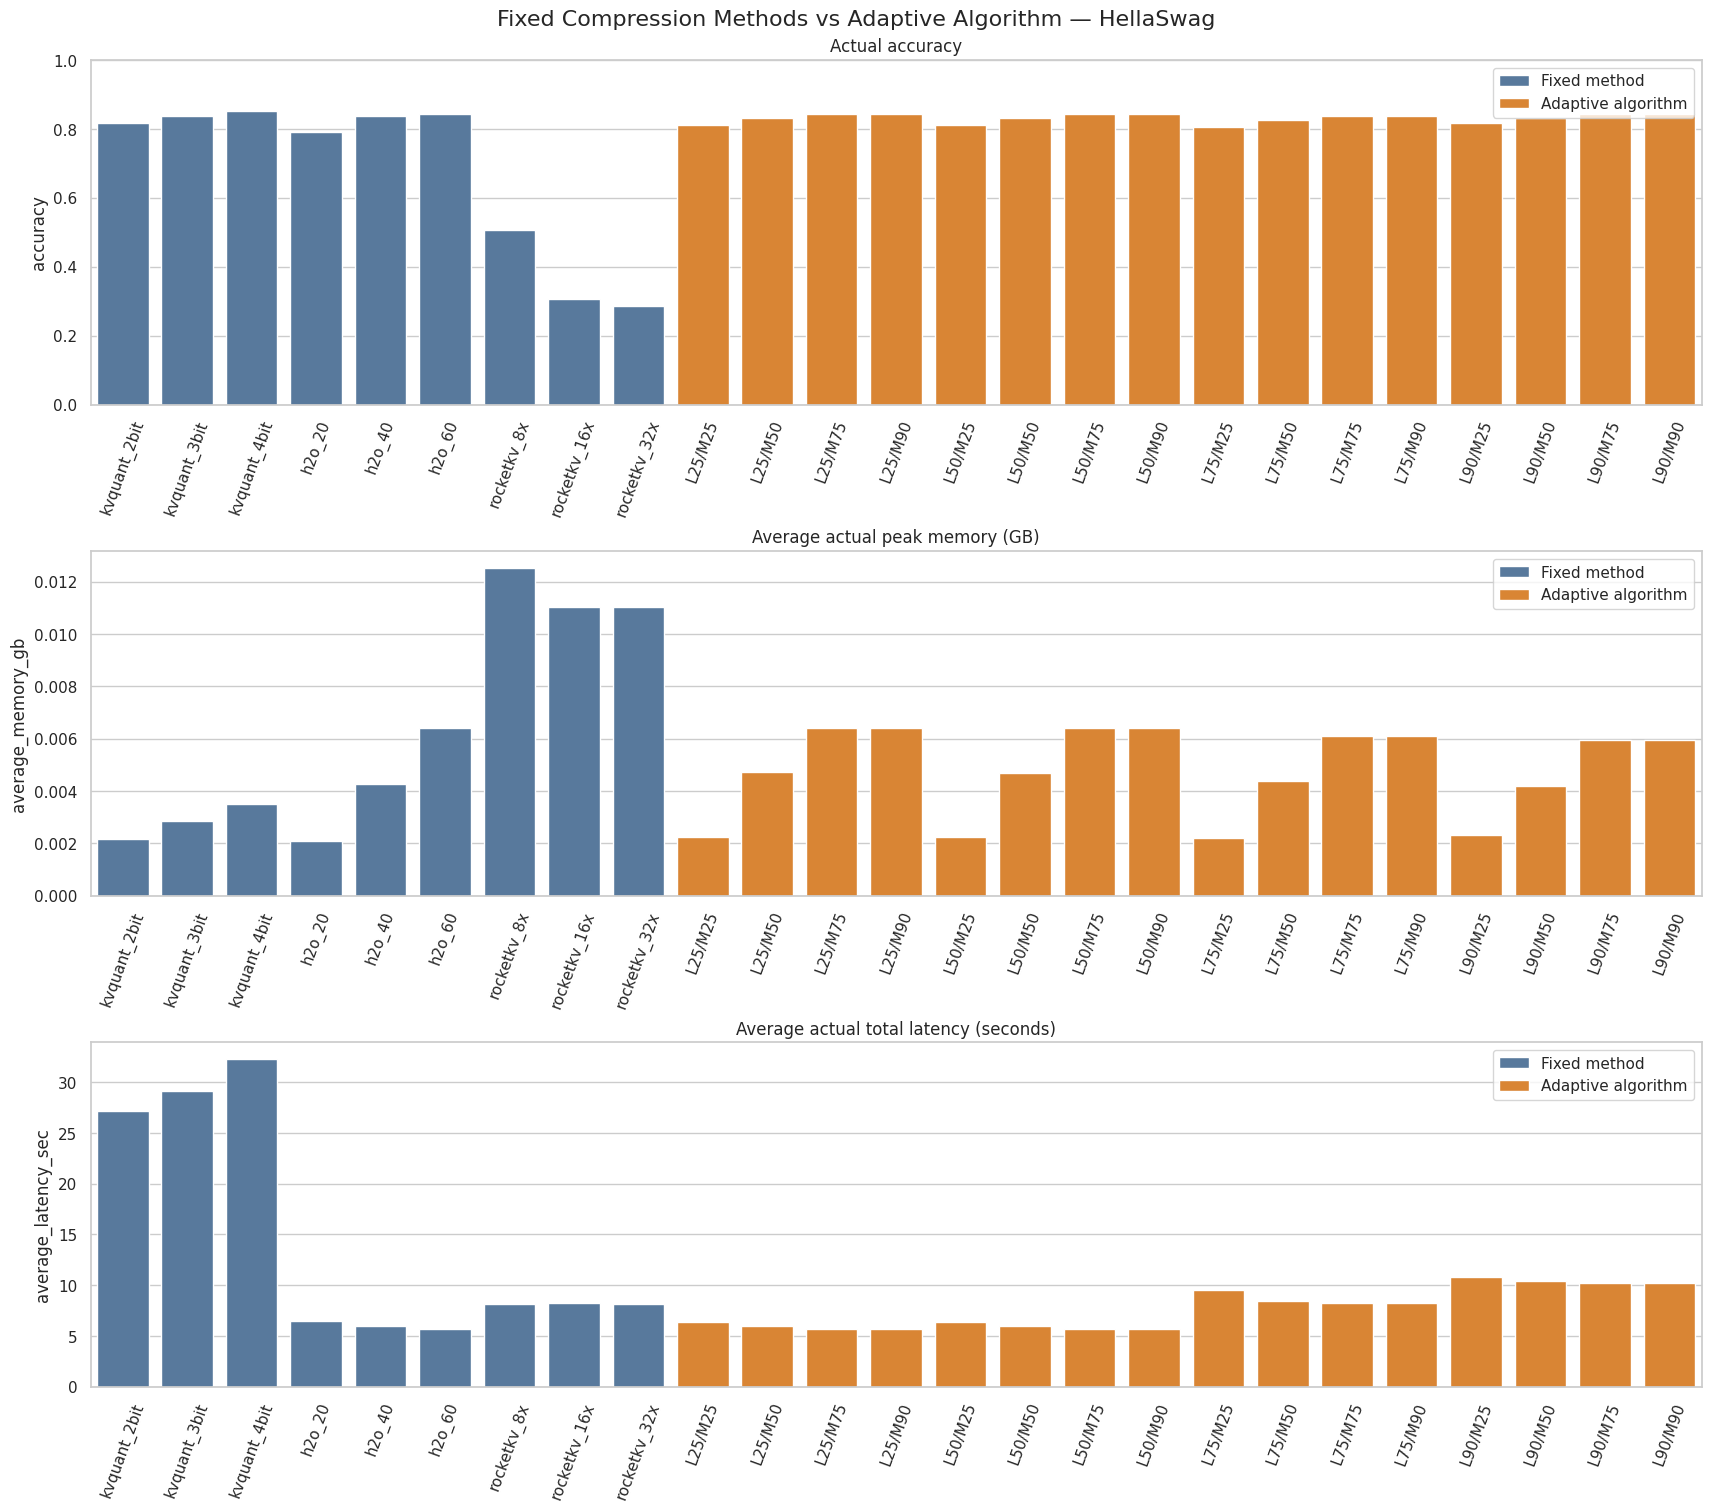

In [ ]:
# ---------------------------------------------------------------------------
# Fixed-method baselines and dataset-specific metric comparisons
# ---------------------------------------------------------------------------
baseline_records = []
test_keys = pd.MultiIndex.from_frame(test_df[key_cols])

for dataset in DATASETS:
    dataset_keys = pd.MultiIndex.from_frame(test_df.loc[test_df.dataset == dataset, key_cols])
    for method in CONFIGS:
        baseline_records.append({
            "dataset": dataset,
            "strategy": method,
            "strategy_type": "Fixed method",
            "accuracy": float(correct_lookup.loc[dataset_keys, method].mean()),
            "average_memory_gb": float(memory_lookup.loc[dataset_keys, method].mean()),
            "average_latency_sec": float(latency_lookup.loc[dataset_keys, method].mean()),
        })

baseline_summary = pd.DataFrame(baseline_records)
adaptive_summary = (
    adaptive_results.groupby(["dataset", "constraint_label"], sort=False)
    .agg(
        accuracy=("actual_correct", "mean"),
        average_memory_gb=("actual_memory_gb", "mean"),
        average_latency_sec=("actual_latency_sec", "mean"),
    )
    .reset_index()
    .rename(columns={"constraint_label": "strategy"})
)
adaptive_summary["strategy_type"] = "Adaptive algorithm"

performance_summary = pd.concat(
    [baseline_summary, adaptive_summary], ignore_index=True
)
performance_summary.to_csv(OUTPUT_DIR / "dataset_performance_summary.csv", index=False)

sns.set_theme(style="whitegrid")
palette = {
    "Fixed method": "#4C78A8",
    "Adaptive algorithm": "#F58518",
}

for dataset in DATASETS:
    plot_data = performance_summary[performance_summary.dataset == dataset].copy()
    plot_data["average_memory_mb"] = plot_data["average_memory_gb"] * 1024
    fig, axes = plt.subplots(3, 1, figsize=(17, 15), constrained_layout=True)
    metrics = [
        ("accuracy", "Actual accuracy", (0, 1)),
        ("average_memory_mb", "Average actual peak memory (MB)", None),
        ("average_latency_sec", "Average actual total latency (seconds)", None),
    ]
    for axis, (metric, title, ylim) in zip(axes, metrics):
        sns.barplot(
            data=plot_data,
            x="strategy",
            y=metric,
            hue="strategy_type",
            dodge=False,
            palette=palette,
            ax=axis,
        )
        axis.set_title(title)
        axis.set_xlabel("")
        axis.tick_params(axis="x", rotation=70)
        if ylim:
            axis.set_ylim(*ylim)
        axis.legend(title="", loc="best")
    fig.suptitle(
        f"Fixed Compression Methods vs Adaptive Algorithm — {DATASET_TITLES[dataset]}",
        fontsize=16,
    )
    fig.savefig(OUTPUT_DIR / f"performance_{dataset}.png", dpi=200, bbox_inches="tight")
    plt.show()


## 9. Plot selection frequencies


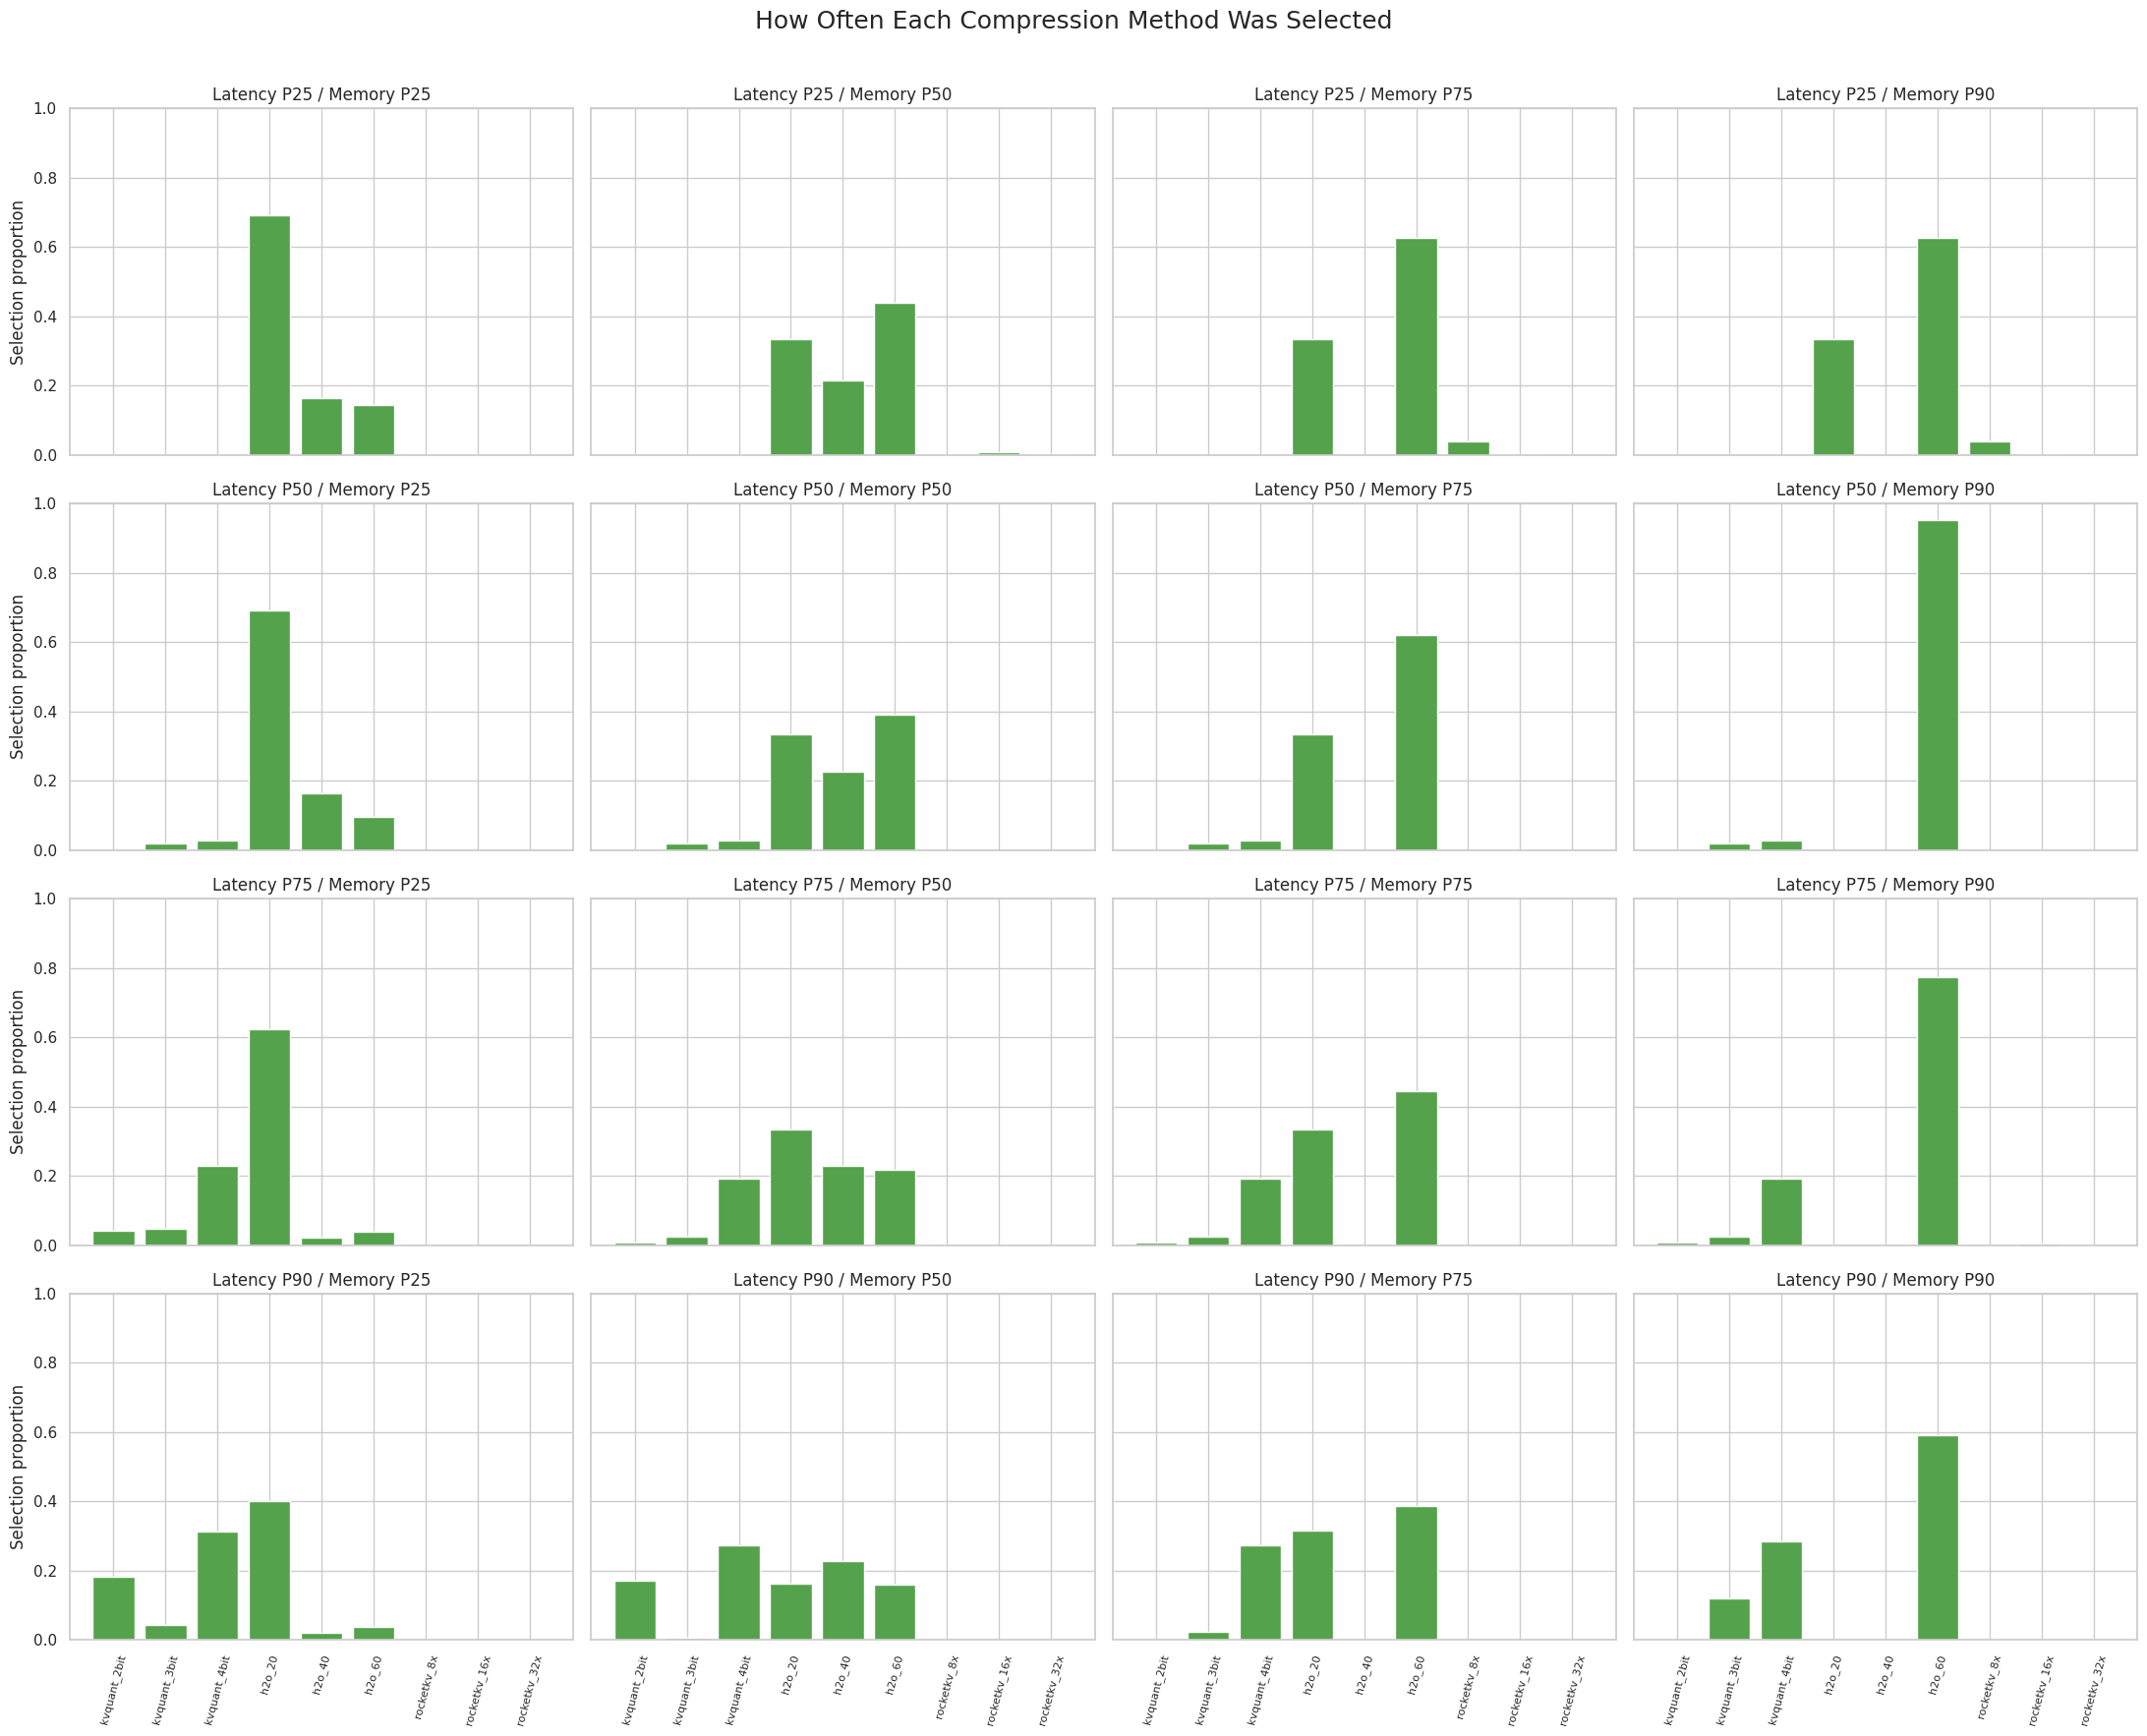

In [ ]:
# ---------------------------------------------------------------------------
# Selection frequency: one subplot for every threshold combination
# ---------------------------------------------------------------------------
selection_counts = (
    adaptive_results.groupby(
        ["latency_percentile", "memory_percentile", "constraint_label", "selected_method"]
    )
    .size()
    .rename("selection_count")
    .reset_index()
)
totals = adaptive_results.groupby("constraint_label").size().rename("total")
selection_counts = selection_counts.join(totals, on="constraint_label")
selection_counts["selection_proportion"] = (
    selection_counts["selection_count"] / selection_counts["total"]
)
selection_counts.to_csv(OUTPUT_DIR / "selection_frequencies.csv", index=False)

fig, axes = plt.subplots(4, 4, figsize=(22, 18), sharex=True, sharey=True)
for row_index, latency_pct in enumerate(PERCENTILES):
    for col_index, memory_pct in enumerate(PERCENTILES):
        axis = axes[row_index, col_index]
        subset = adaptive_results[
            (adaptive_results.latency_percentile == latency_pct)
            & (adaptive_results.memory_percentile == memory_pct)
        ]
        proportions = (
            subset["selected_method"].value_counts(normalize=True).reindex(CONFIGS, fill_value=0)
        )
        axis.bar(CONFIGS, proportions.values, color="#54A24B")
        axis.set_title(f"Latency P{latency_pct} / Memory P{memory_pct}")
        axis.set_ylim(0, 1)
        axis.tick_params(axis="x", rotation=75, labelsize=8)
        if col_index == 0:
            axis.set_ylabel("Selection proportion")
fig.suptitle("How Often Each Compression Method Was Selected", fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUTPUT_DIR / "selection_frequency_grid.png", dpi=200, bbox_inches="tight")
plt.show()


## 10. Plot actual constraint violations


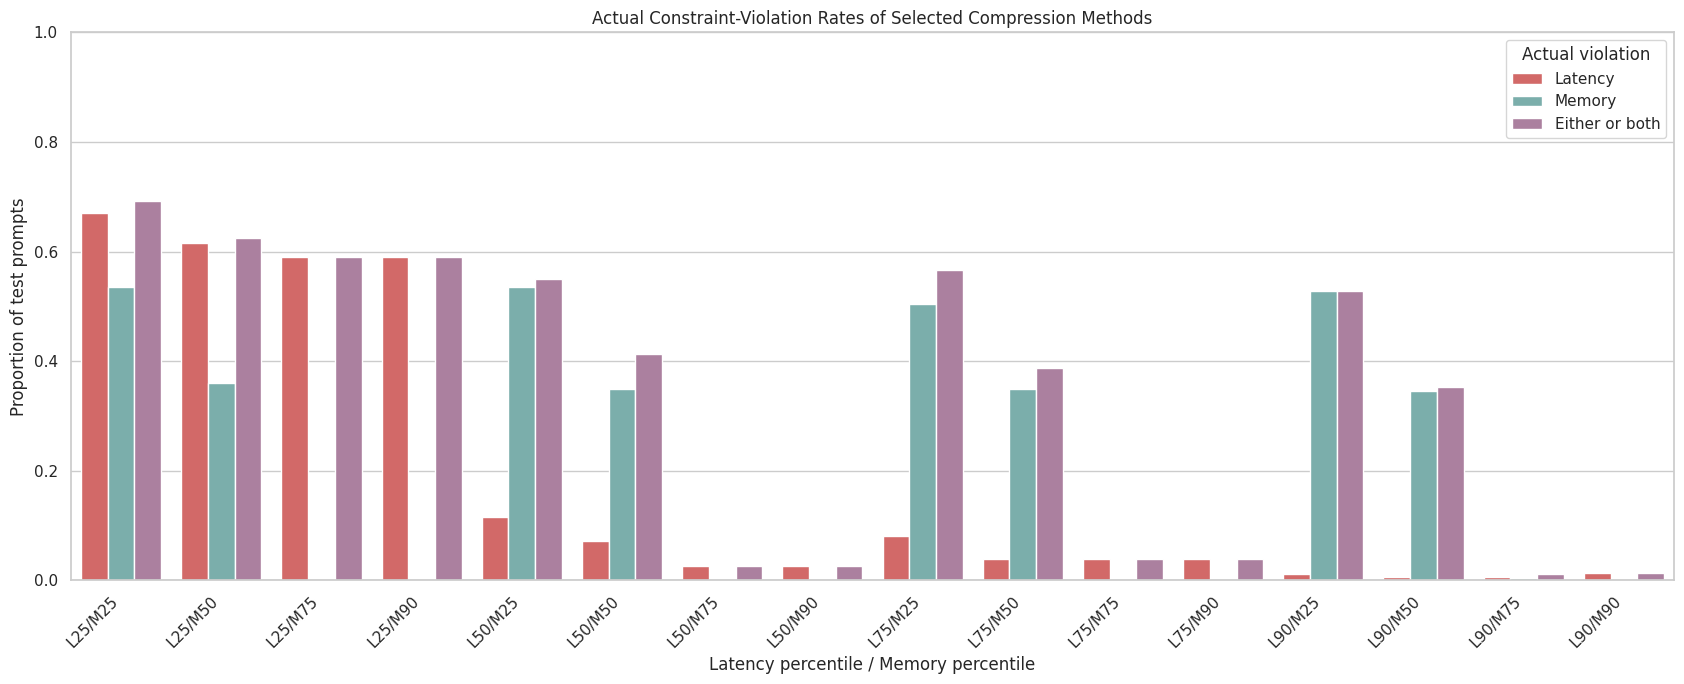


Finished. Tables and graphs were saved to: /content/drive/MyDrive/KV_Cache_Models/adaptive_evaluation

Dataset-specific performance summary:
      dataset     strategy      strategy_type  accuracy  average_memory_gb  average_latency_sec
        gsm8k kvquant_2bit       Fixed method  0.311688           0.023243            21.956433
        gsm8k kvquant_3bit       Fixed method  0.435065           0.030465            23.438310
        gsm8k kvquant_4bit       Fixed method  0.454545           0.037651            26.317439
        gsm8k       h2o_20       Fixed method  0.487013           0.023187             5.551819
        gsm8k       h2o_40       Fixed method  0.493506           0.046384             5.586951
        gsm8k       h2o_60       Fixed method  0.454545           0.069655             5.790020
        gsm8k  rocketkv_8x       Fixed method  0.480519           0.105070            17.009074
        gsm8k rocketkv_16x       Fixed method  0.389610           0.085372            17.1

In [ ]:
# ---------------------------------------------------------------------------
# Actual constraint-violation rates for the selected methods
# ---------------------------------------------------------------------------
violation_summary = (
    adaptive_results.groupby(
        ["latency_percentile", "memory_percentile", "constraint_label"], sort=False
    )
    .agg(
        latency_violation_rate=("latency_violation", "mean"),
        memory_violation_rate=("memory_violation", "mean"),
        any_violation_rate=("any_violation", "mean"),
        fallback_rate=("used_fallback", "mean"),
    )
    .reset_index()
)
violation_summary.to_csv(OUTPUT_DIR / "constraint_violation_summary.csv", index=False)

violation_long = violation_summary.melt(
    id_vars="constraint_label",
    value_vars=[
        "latency_violation_rate", "memory_violation_rate", "any_violation_rate"
    ],
    var_name="violation_type",
    value_name="proportion",
)
violation_long["violation_type"] = violation_long["violation_type"].map({
    "latency_violation_rate": "Latency",
    "memory_violation_rate": "Memory",
    "any_violation_rate": "Either or both",
})

plt.figure(figsize=(17, 7))
sns.barplot(
    data=violation_long,
    x="constraint_label",
    y="proportion",
    hue="violation_type",
    palette=["#E45756", "#72B7B2", "#B279A2"],
)
plt.ylim(0, 1)
plt.xlabel("Latency percentile / Memory percentile")
plt.ylabel("Proportion of test prompts")
plt.title("Actual Constraint-Violation Rates of Selected Compression Methods")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Actual violation")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "constraint_violation_rates.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nFinished. Tables and graphs were saved to: {OUTPUT_DIR}")
print("\nDataset-specific performance summary:")
print(performance_summary.to_string(index=False))
print("\nConstraint violation summary:")
print(violation_summary.to_string(index=False))


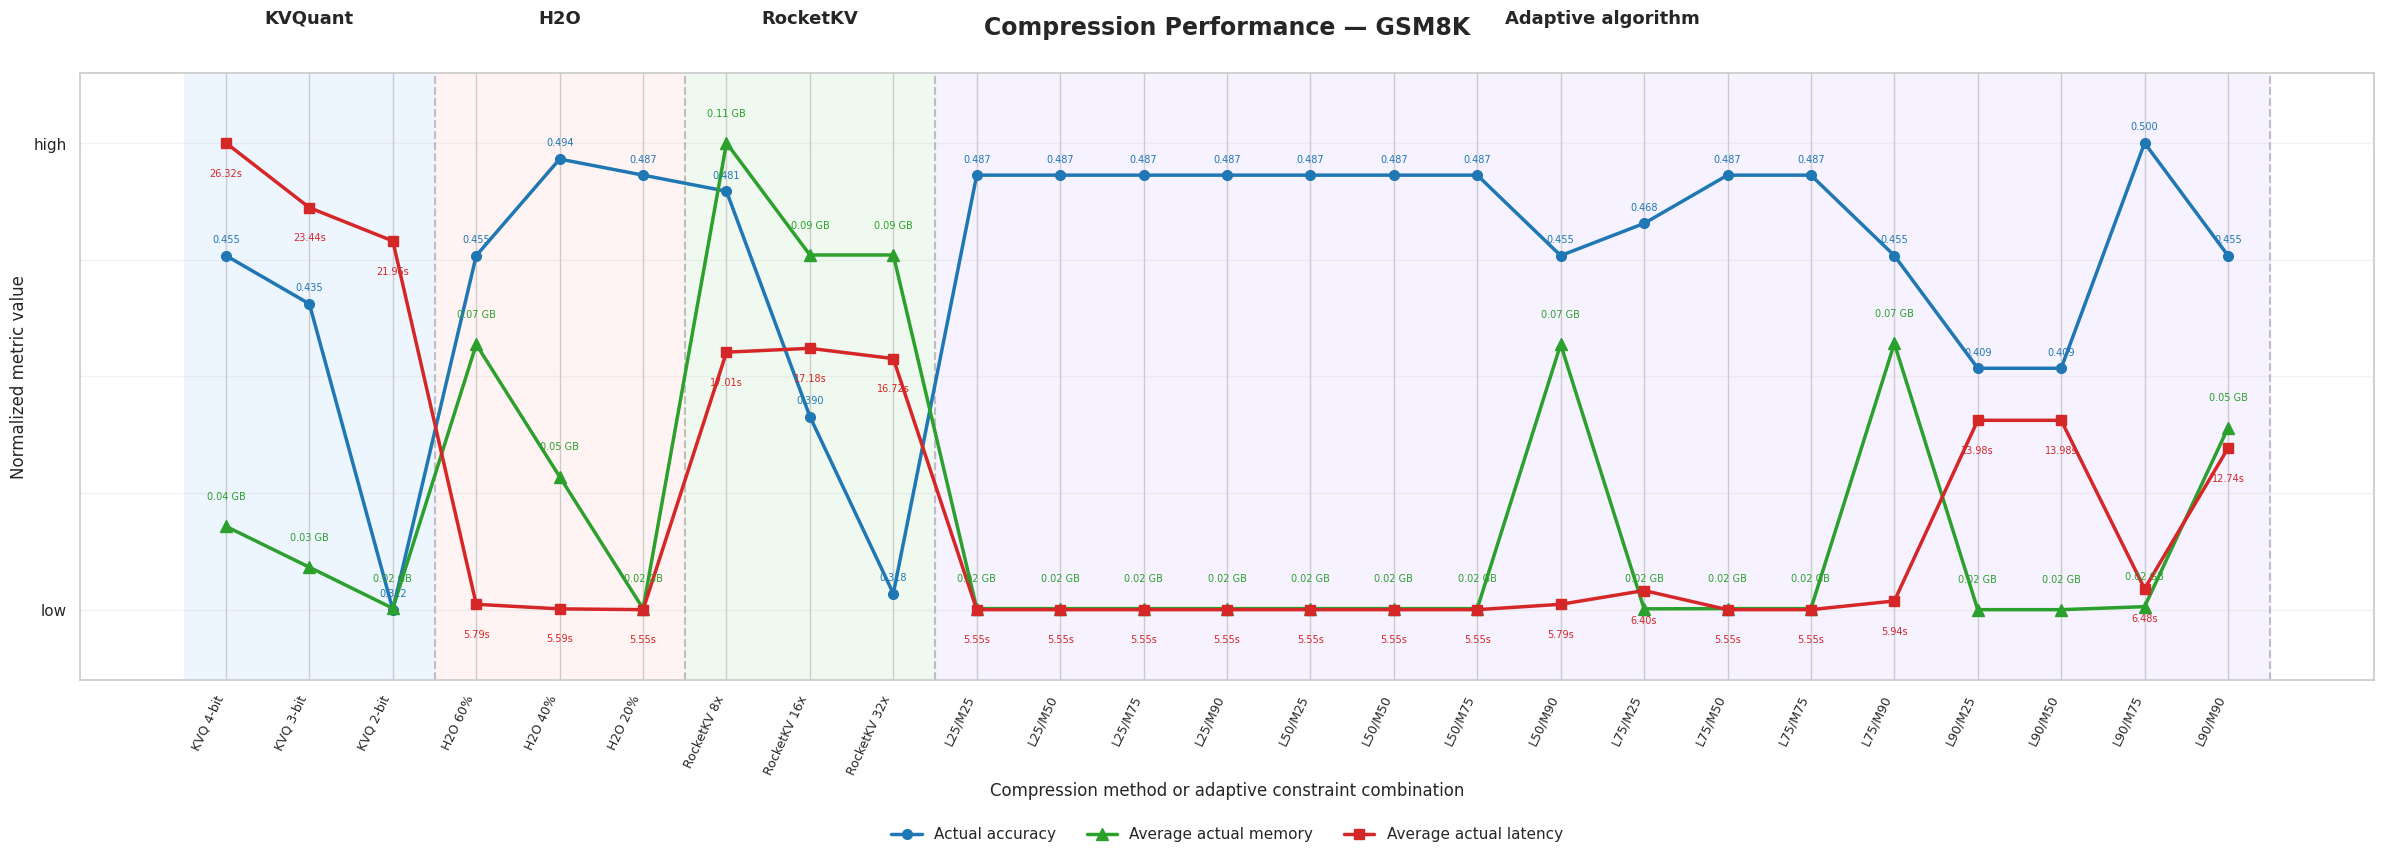

Saved: /content/drive/MyDrive/KV_Cache_Models/adaptive_evaluation/combined_dataset_graphs/combined_performance_gsm8k.png


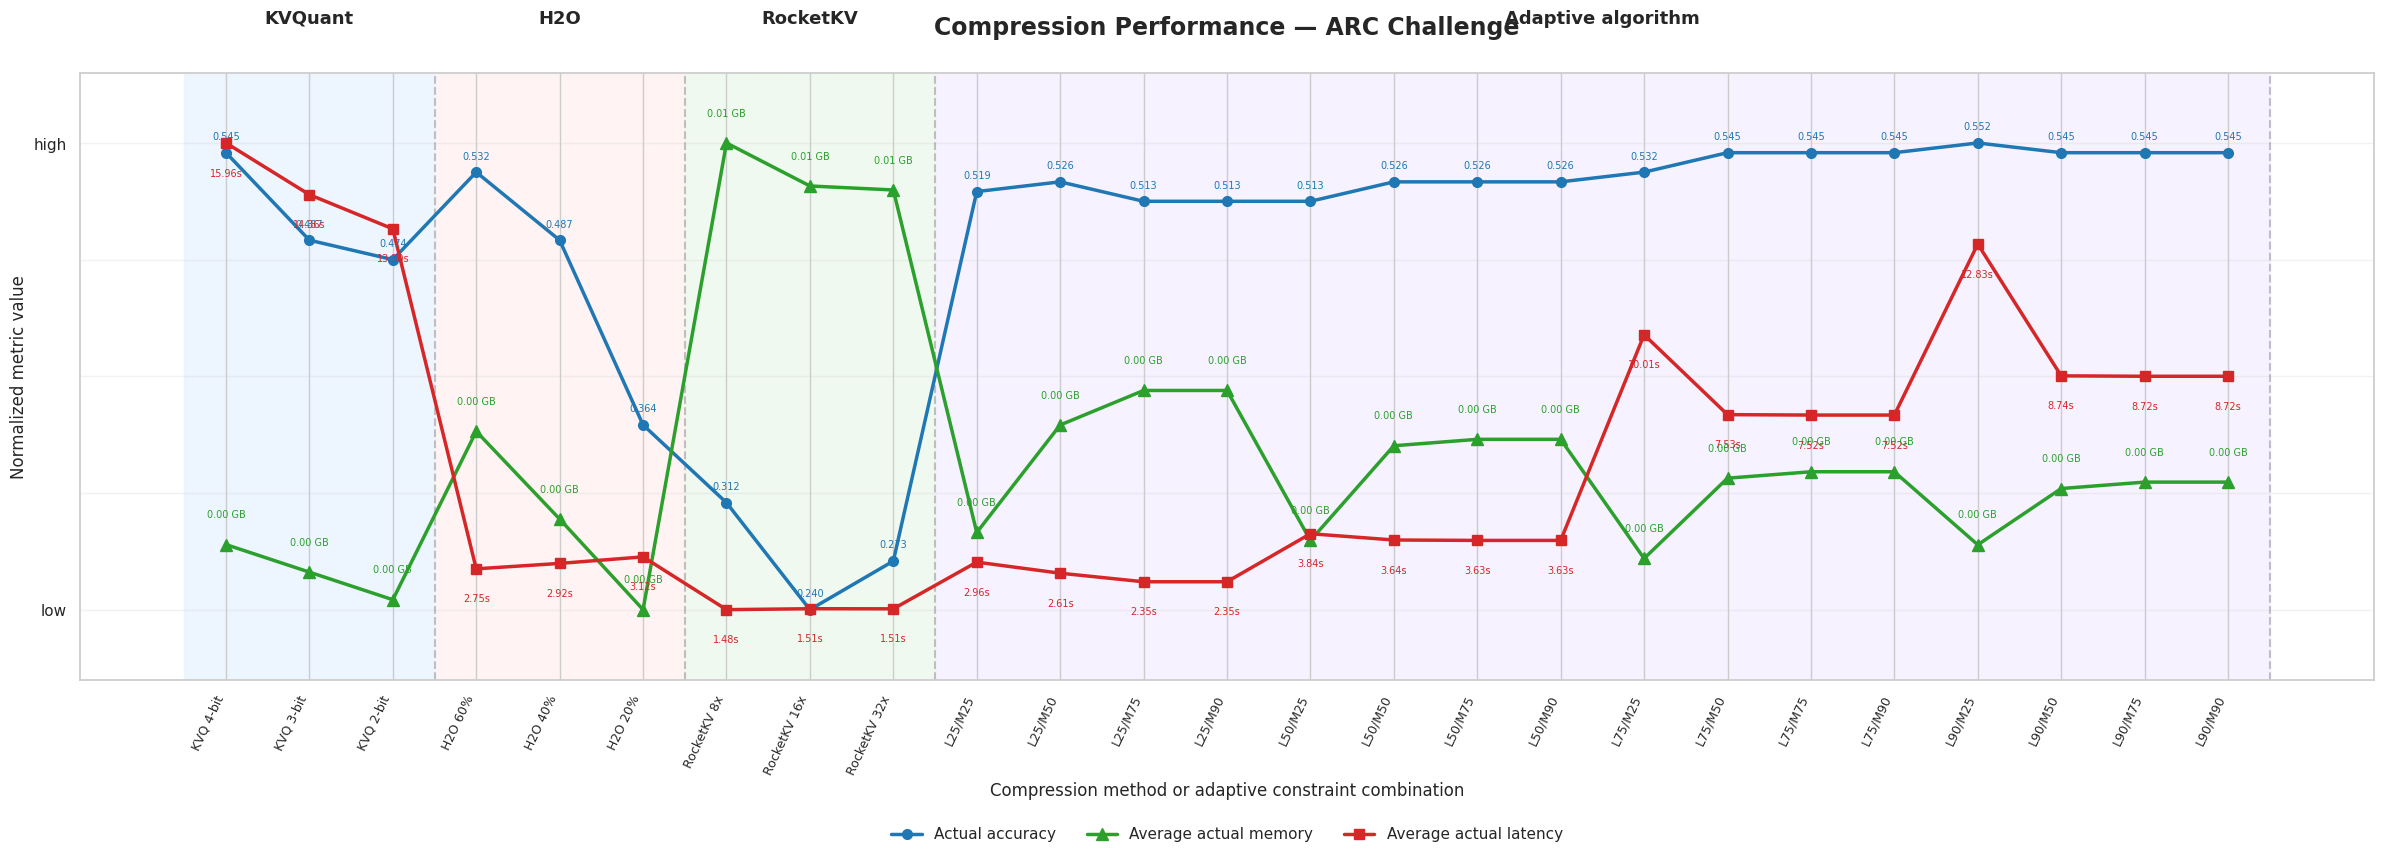

Saved: /content/drive/MyDrive/KV_Cache_Models/adaptive_evaluation/combined_dataset_graphs/combined_performance_arc_challenge.png


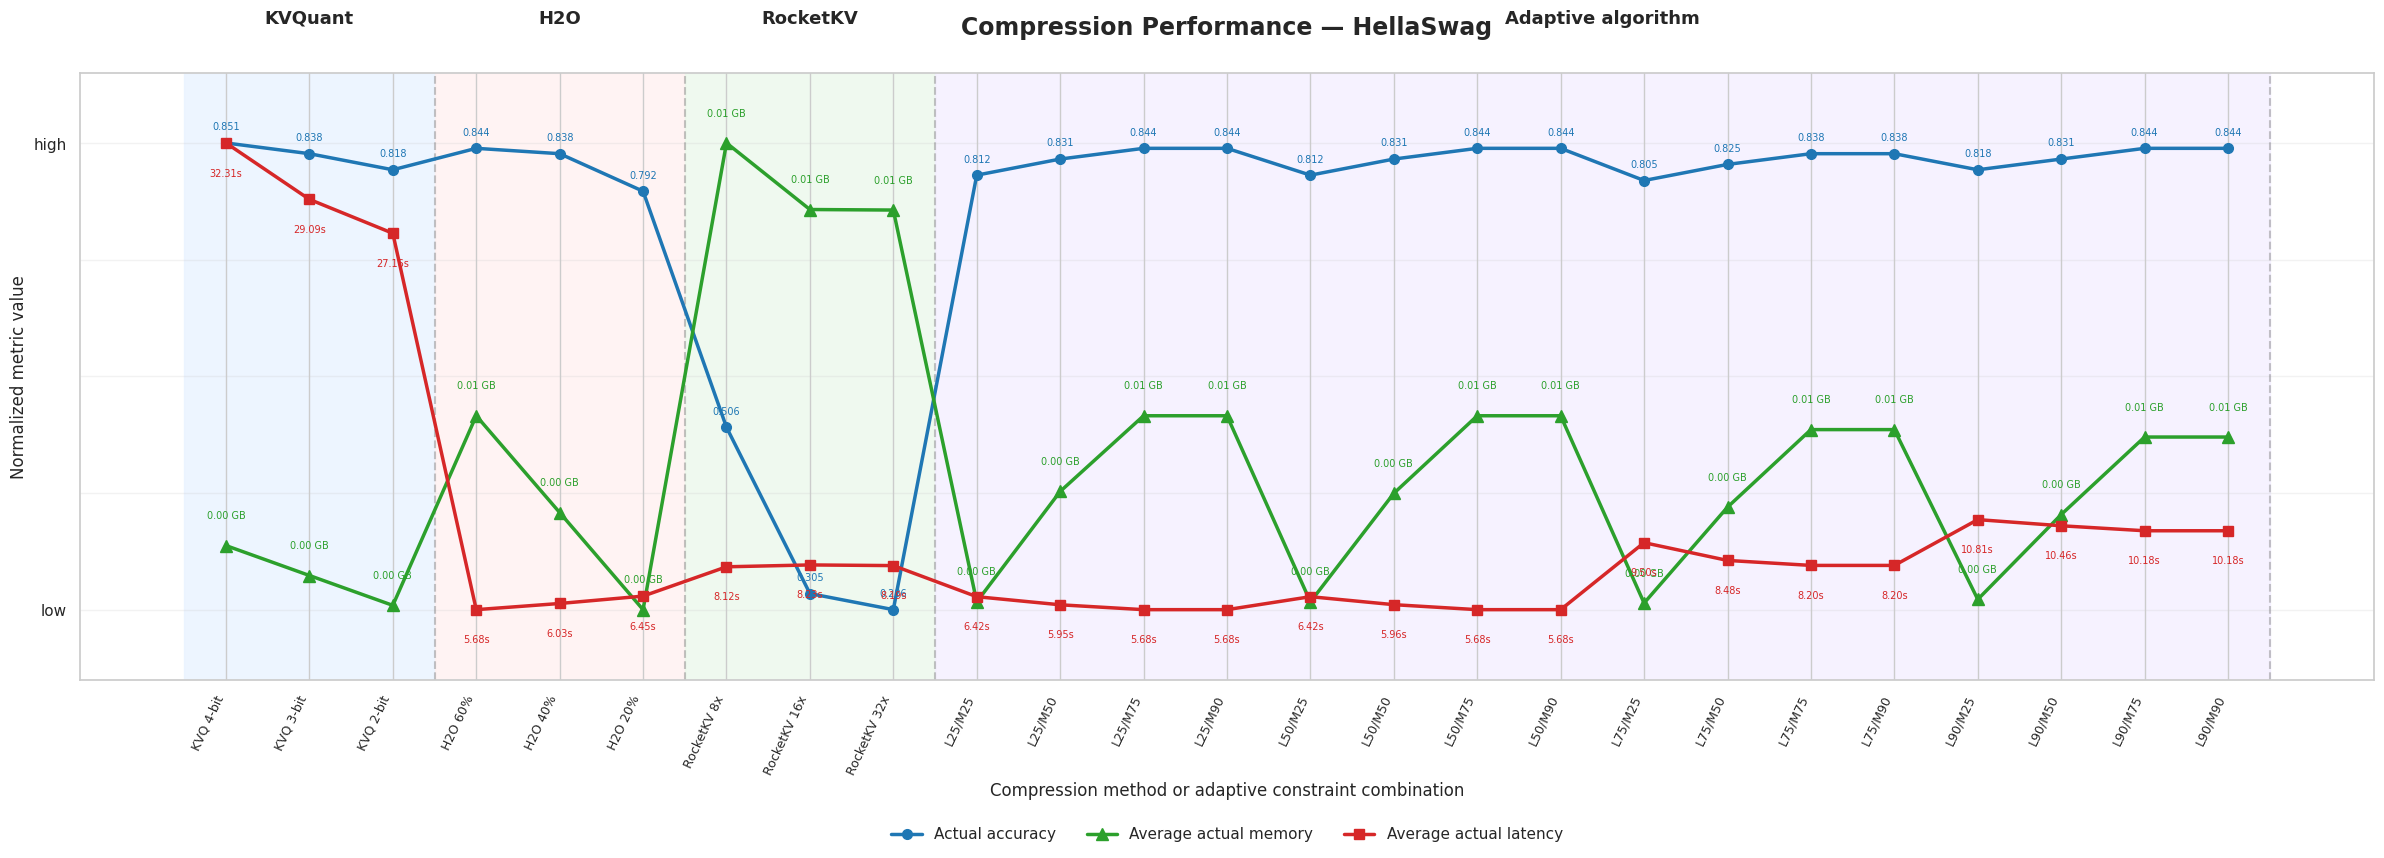

Saved: /content/drive/MyDrive/KV_Cache_Models/adaptive_evaluation/combined_dataset_graphs/combined_performance_hellaswag.png


In [ ]:
# ============================================================================
# ONE COMBINED PERFORMANCE GRAPH PER DATASET
# Blue  = actual accuracy
# Green = average actual peak memory
# Red   = average actual total latency
#
# The plotted heights are min-max normalized within each dataset so metrics
# with different units can share one axis. Point labels show actual values.
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

combined_graph_dir = OUTPUT_DIR / "combined_dataset_graphs"
combined_graph_dir.mkdir(parents=True, exist_ok=True)

# Desired ordering on the x-axis
fixed_order = [
    "kvquant_4bit",
    "kvquant_3bit",
    "kvquant_2bit",
    "h2o_60",
    "h2o_40",
    "h2o_20",
    "rocketkv_8x",
    "rocketkv_16x",
    "rocketkv_32x",
]

adaptive_order = [
    f"L{latency_pct}/M{memory_pct}"
    for latency_pct in PERCENTILES
    for memory_pct in PERCENTILES
]

strategy_order = fixed_order + adaptive_order

display_names = {
    "kvquant_4bit": "KVQ 4-bit",
    "kvquant_3bit": "KVQ 3-bit",
    "kvquant_2bit": "KVQ 2-bit",
    "h2o_60": "H2O 60%",
    "h2o_40": "H2O 40%",
    "h2o_20": "H2O 20%",
    "rocketkv_8x": "RocketKV 8x",
    "rocketkv_16x": "RocketKV 16x",
    "rocketkv_32x": "RocketKV 32x",
}


def minmax(values):
    """Normalize values to [0, 1]."""
    values = np.asarray(values, dtype=float)
    value_min = values.min()
    value_max = values.max()

    if np.isclose(value_min, value_max):
        return np.full_like(values, 0.5)

    return (values - value_min) / (value_max - value_min)


def add_point_labels(axis, x, y, actual_values, color, formatter, offset):
    """Label each point with its actual, non-normalized value."""
    for xi, yi, value in zip(x, y, actual_values):
        axis.annotate(
            formatter(value),
            xy=(xi, yi),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            va="bottom" if offset >= 0 else "top",
            fontsize=7,
            color=color,
            rotation=0,
        )


for dataset in DATASETS:
    graph_data = performance_summary[
        performance_summary["dataset"] == dataset
    ].copy()

    # Put the nine fixed methods first, followed by the 16 adaptive settings.
    graph_data["strategy"] = pd.Categorical(
        graph_data["strategy"],
        categories=strategy_order,
        ordered=True,
    )

    graph_data = (
        graph_data.dropna(subset=["strategy"])
        .sort_values("strategy")
        .reset_index(drop=True)
    )

    graph_data["strategy"] = graph_data["strategy"].astype(str)

    x = np.arange(len(graph_data))

    actual_accuracy = graph_data["accuracy"].to_numpy()
    actual_memory = graph_data["average_memory_gb"].to_numpy() * 1024  # GB -> MB for display
    actual_latency = graph_data["average_latency_sec"].to_numpy()

    normalized_accuracy = minmax(actual_accuracy)
    normalized_memory = minmax(actual_memory)
    normalized_latency = minmax(actual_latency)

    fig, ax = plt.subplots(figsize=(24, 9))

    # ------------------------------------------------------------------------
    # Background regions for compression families and adaptive configurations
    # ------------------------------------------------------------------------
    regions = [
        (-0.5, 2.5, "#E8F2FF", "KVQuant"),
        (2.5, 5.5, "#FFF0F0", "H2O"),
        (5.5, 8.5, "#EAF8EA", "RocketKV"),
        (8.5, len(graph_data) - 0.5, "#F3EEFF", "Adaptive algorithm"),
    ]

    for start, end, color, label in regions:
        ax.axvspan(start, end, color=color, alpha=0.75, zorder=0)
        ax.axvline(end, color="gray", linestyle="--", alpha=0.45)

        center = (start + end) / 2
        ax.text(
            center,
            1.075,
            label,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontsize=13,
            fontweight="bold",
        )

    # ------------------------------------------------------------------------
    # Plot the three normalized metrics
    # ------------------------------------------------------------------------
    ax.plot(
        x,
        normalized_accuracy,
        color="#1f77b4",
        marker="o",
        linewidth=2.5,
        markersize=7,
        label="Actual accuracy",
        zorder=3,
    )

    ax.plot(
        x,
        normalized_memory,
        color="#2ca02c",
        marker="^",
        linewidth=2.5,
        markersize=8,
        label="Average actual memory",
        zorder=3,
    )

    ax.plot(
        x,
        normalized_latency,
        color="#d62728",
        marker="s",
        linewidth=2.5,
        markersize=7,
        label="Average actual latency",
        zorder=3,
    )

    # Actual-value labels
    add_point_labels(
        ax,
        x,
        normalized_accuracy,
        actual_accuracy,
        "#1f77b4",
        lambda value: f"{value:.3f}",
        8,
    )

    add_point_labels(
        ax,
        x,
        normalized_memory,
        actual_memory,
        "#2ca02c",
        lambda value: f"{value:.3f} MB",
        18,
    )

    add_point_labels(
        ax,
        x,
        normalized_latency,
        actual_latency,
        "#d62728",
        lambda value: f"{value:.2f}s",
        -18,
    )

    x_labels = [
        display_names.get(strategy, strategy)
        for strategy in graph_data["strategy"]
    ]

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=65, ha="right", fontsize=9)

    ax.set_ylim(-0.15, 1.15)
    ax.set_yticks([0, 0.25, 0.50, 0.75, 1.0])
    ax.set_yticklabels(["low", "", "", "", "high"])

    ax.set_ylabel("Normalized metric value", fontsize=12)
    ax.set_xlabel("Compression method or adaptive constraint combination")
    ax.set_title(
        f"Compression Performance — {DATASET_TITLES[dataset]}",
        fontsize=17,
        fontweight="bold",
        pad=28,
    )

    ax.grid(axis="y", alpha=0.25)
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
        ncol=3,
        frameon=False,
        fontsize=11,
    )

    plt.tight_layout()

    save_path = combined_graph_dir / f"combined_performance_{dataset}.png"
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()

    print(f"Saved: {save_path}")

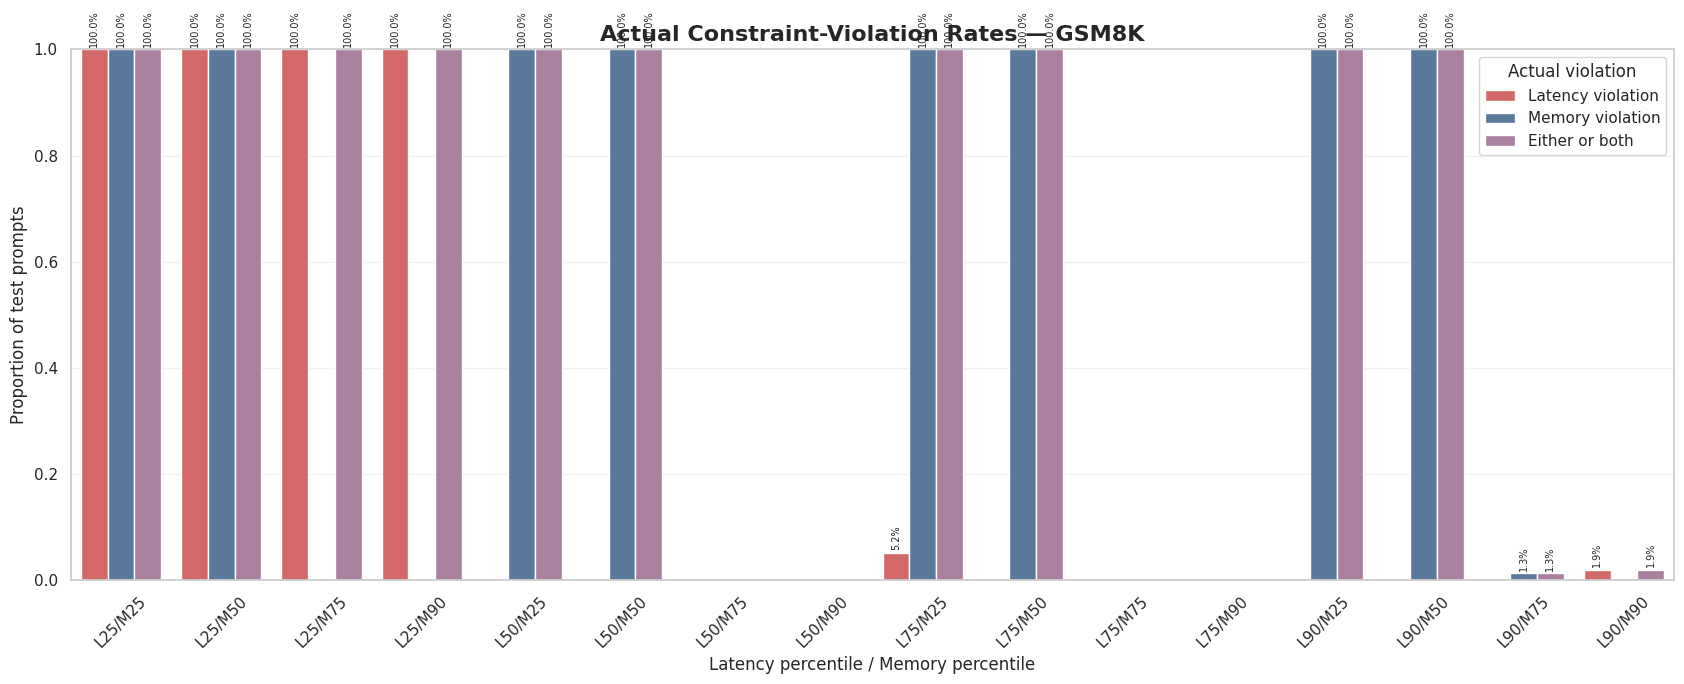

Saved: /content/drive/MyDrive/KV_Cache_Models/adaptive_evaluation/dataset_violation_graphs/constraint_violations_gsm8k.png


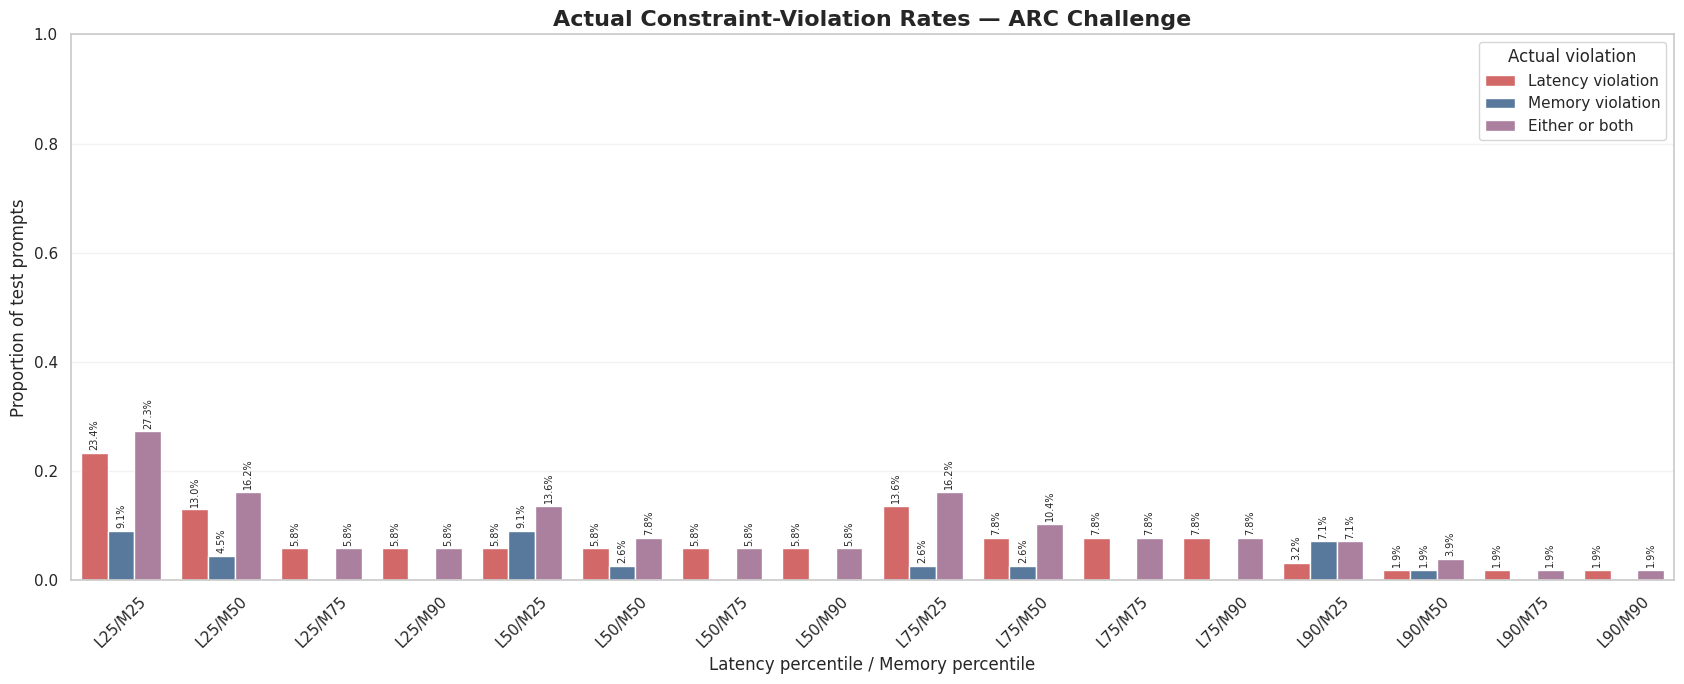

Saved: /content/drive/MyDrive/KV_Cache_Models/adaptive_evaluation/dataset_violation_graphs/constraint_violations_arc_challenge.png


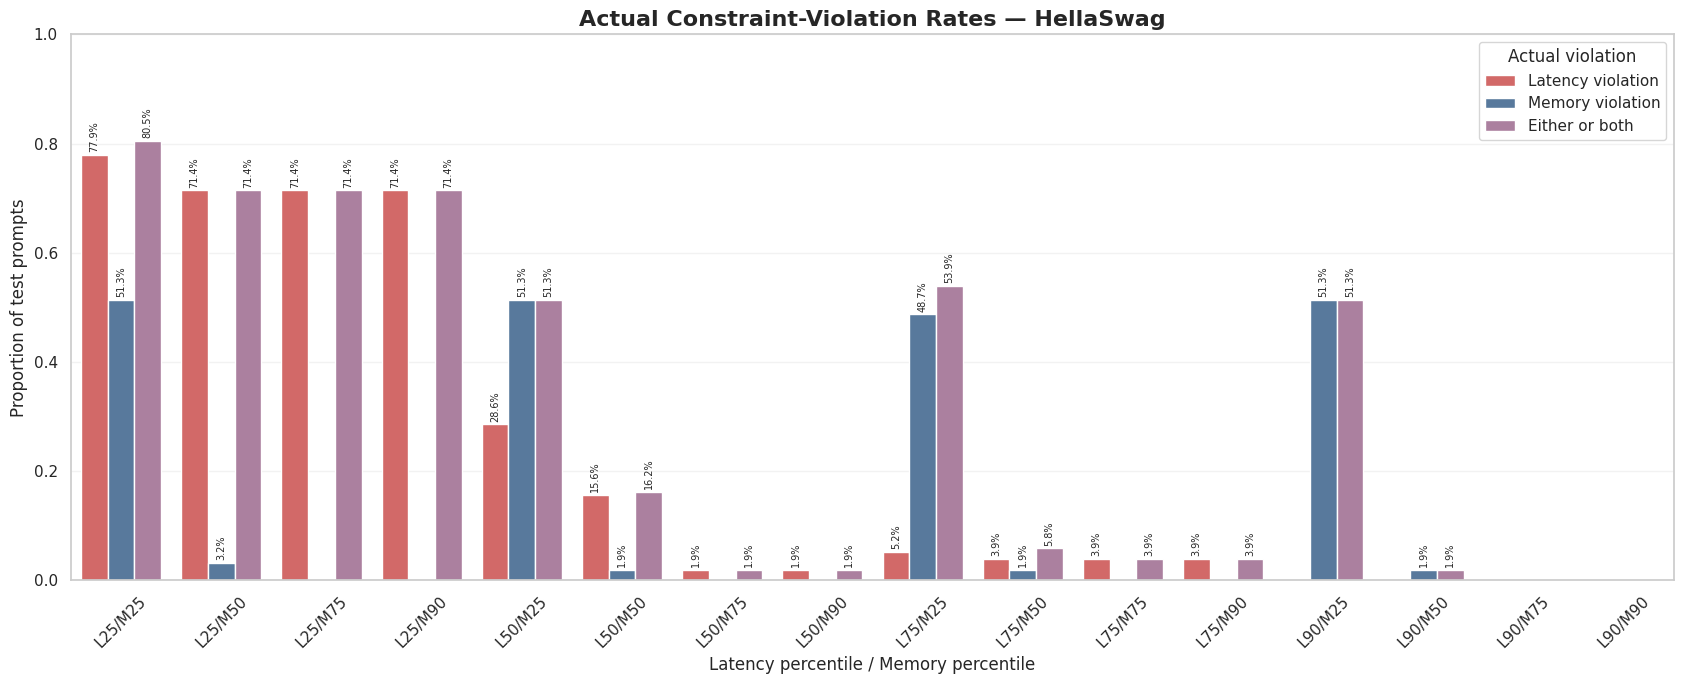

Saved: /content/drive/MyDrive/KV_Cache_Models/adaptive_evaluation/dataset_violation_graphs/constraint_violations_hellaswag.png

Dataset-specific violation rates:


,dataset,latency_percentile,memory_percentile,constraint_label,latency_violation_rate,memory_violation_rate,any_violation_rate,fallback_rate,number_of_prompts
1,arc_challenge,25,25,L25/M25,0.233766,0.090909,0.272727,0.214286,154
4,arc_challenge,25,50,L25/M50,0.129870,0.045455,0.162338,0.123377,154
7,arc_challenge,25,75,L25/M75,0.058442,0.000000,0.058442,0.006494,154
10,arc_challenge,25,90,L25/M90,0.058442,0.000000,0.058442,0.006494,154
13,arc_challenge,50,25,L50/M25,0.058442,0.090909,0.136364,0.012987,154
16,arc_challenge,50,50,L50/M50,0.058442,0.025974,0.077922,0.000000,154
19,arc_challenge,50,75,L50/M75,0.058442,0.000000,0.058442,0.000000,154
22,arc_challenge,50,90,L50/M90,0.058442,0.000000,0.058442,0.000000,154
25,arc_challenge,75,25,L75/M25,0.136364,0.025974,0.162338,0.012987,154
28,arc_challenge,75,50,L75/M50,0.077922,0.025974,0.103896,0.000000,154


In [ ]:
# ============================================================================
# CONSTRAINT-VIOLATION GRAPH FOR EACH DATASET
# Shows the proportion of selected methods whose ACTUAL measured latency,
# memory, or either metric exceeded the current predicted-selection constraint.
# ============================================================================

dataset_violation_dir = OUTPUT_DIR / "dataset_violation_graphs"
dataset_violation_dir.mkdir(parents=True, exist_ok=True)

dataset_violation_summary = (
    adaptive_results.groupby(
        [
            "dataset",
            "latency_percentile",
            "memory_percentile",
            "constraint_label",
        ],
        sort=False,
    )
    .agg(
        latency_violation_rate=("latency_violation", "mean"),
        memory_violation_rate=("memory_violation", "mean"),
        any_violation_rate=("any_violation", "mean"),
        fallback_rate=("used_fallback", "mean"),
        number_of_prompts=("idx", "size"),
    )
    .reset_index()
)

# Preserve the intended 4 × 4 constraint ordering
constraint_order = [
    f"L{latency_pct}/M{memory_pct}"
    for latency_pct in PERCENTILES
    for memory_pct in PERCENTILES
]

dataset_violation_summary["constraint_label"] = pd.Categorical(
    dataset_violation_summary["constraint_label"],
    categories=constraint_order,
    ordered=True,
)

dataset_violation_summary = dataset_violation_summary.sort_values(
    ["dataset", "constraint_label"]
)

# Save the exact numerical results
dataset_violation_summary.to_csv(
    dataset_violation_dir / "dataset_constraint_violation_summary.csv",
    index=False,
)

for dataset in DATASETS:
    dataset_data = dataset_violation_summary[
        dataset_violation_summary["dataset"] == dataset
    ].copy()

    violation_long = dataset_data.melt(
        id_vars=[
            "dataset",
            "constraint_label",
            "latency_percentile",
            "memory_percentile",
        ],
        value_vars=[
            "latency_violation_rate",
            "memory_violation_rate",
            "any_violation_rate",
        ],
        var_name="violation_type",
        value_name="proportion",
    )

    violation_long["violation_type"] = violation_long[
        "violation_type"
    ].map(
        {
            "latency_violation_rate": "Latency violation",
            "memory_violation_rate": "Memory violation",
            "any_violation_rate": "Either or both",
        }
    )

    violation_long["constraint_label"] = pd.Categorical(
        violation_long["constraint_label"],
        categories=constraint_order,
        ordered=True,
    )

    violation_long = violation_long.sort_values("constraint_label")

    plt.figure(figsize=(17, 7))

    axis = sns.barplot(
        data=violation_long,
        x="constraint_label",
        y="proportion",
        hue="violation_type",
        order=constraint_order,
        hue_order=[
            "Latency violation",
            "Memory violation",
            "Either or both",
        ],
        palette={
            "Latency violation": "#E45756",
            "Memory violation": "#4C78A8",
            "Either or both": "#B279A2",
        },
    )

    axis.set_ylim(0, 1)
    axis.set_xlabel("Latency percentile / Memory percentile")
    axis.set_ylabel("Proportion of test prompts")
    axis.set_title(
        f"Actual Constraint-Violation Rates — {DATASET_TITLES[dataset]}",
        fontsize=16,
        fontweight="bold",
    )

    axis.tick_params(axis="x", rotation=45)
    axis.legend(title="Actual violation", loc="upper right")
    axis.grid(axis="y", alpha=0.25)

    # Display percentages above each bar
    for container in axis.containers:
        axis.bar_label(
            container,
            labels=[
                f"{bar.get_height():.1%}"
                if bar.get_height() > 0
                else ""
                for bar in container
            ],
            padding=2,
            fontsize=7,
            rotation=90,
        )

    plt.tight_layout()

    save_path = (
        dataset_violation_dir
        / f"constraint_violations_{dataset}.png"
    )

    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()

    print(f"Saved: {save_path}")

print("\nDataset-specific violation rates:")
display(dataset_violation_summary)

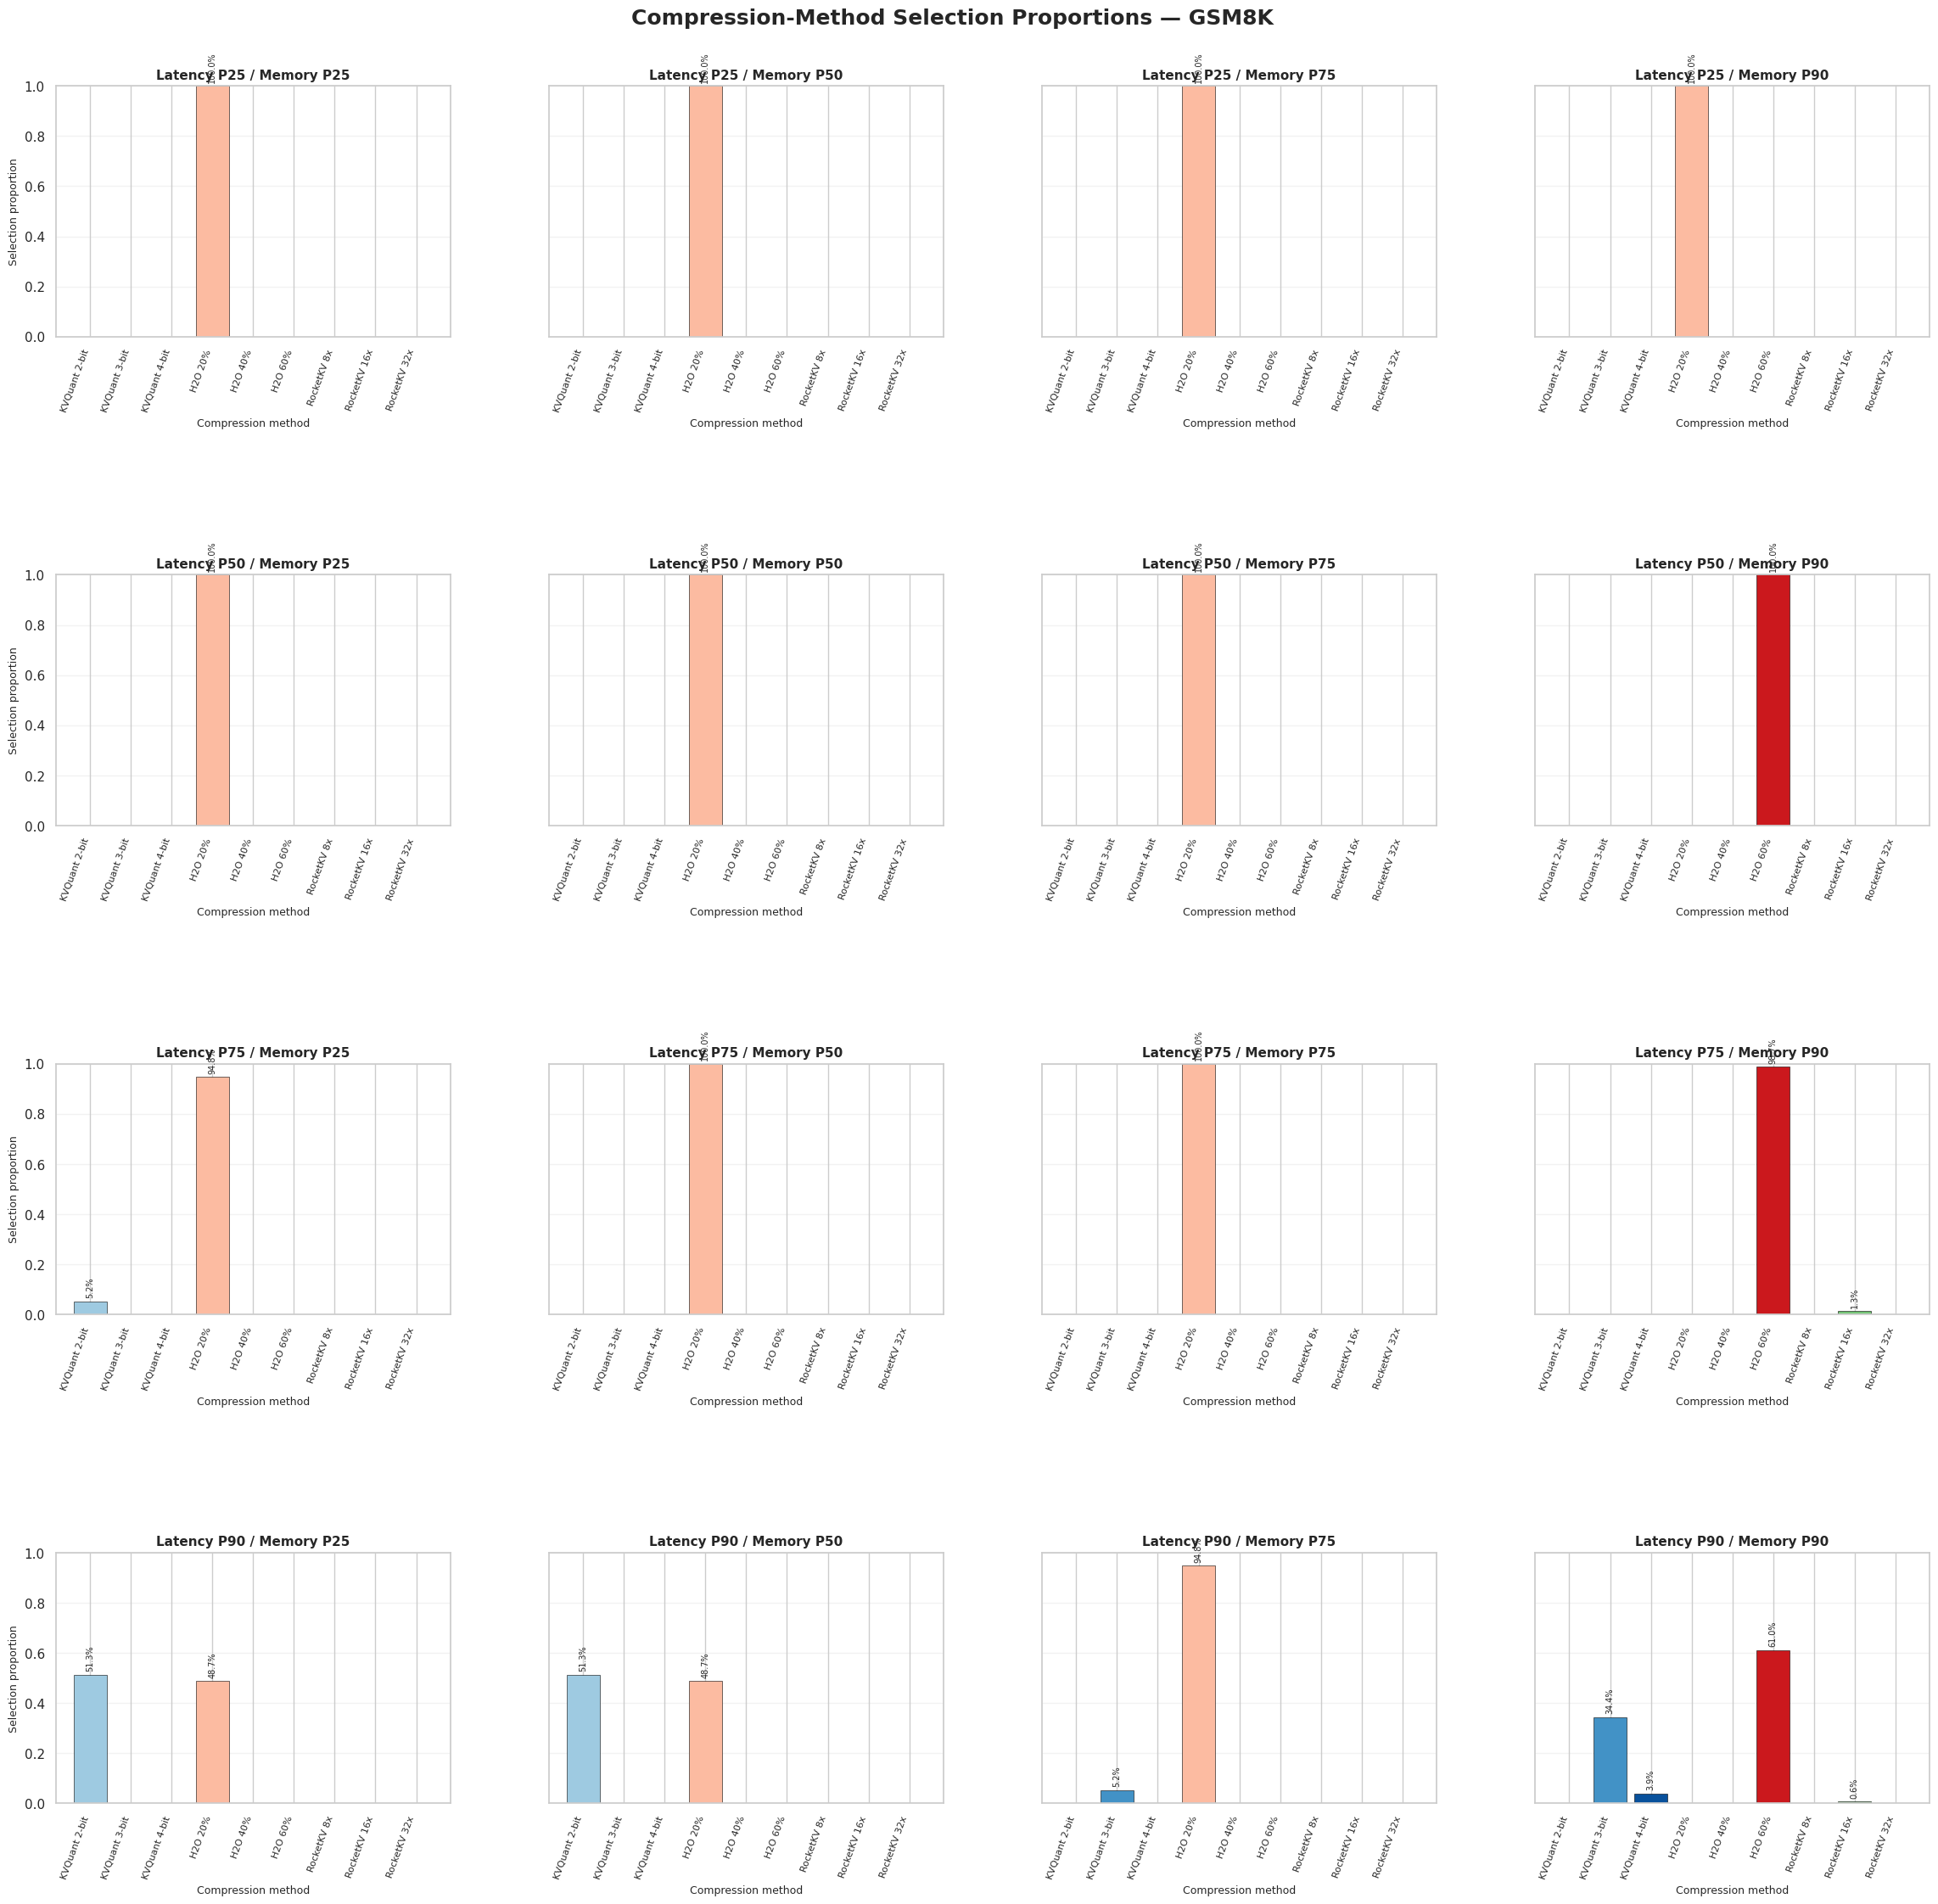

Saved: /content/drive/MyDrive/KV_Cache_Models/adaptive_evaluation/dataset_selection_graphs/selection_proportions_gsm8k.png


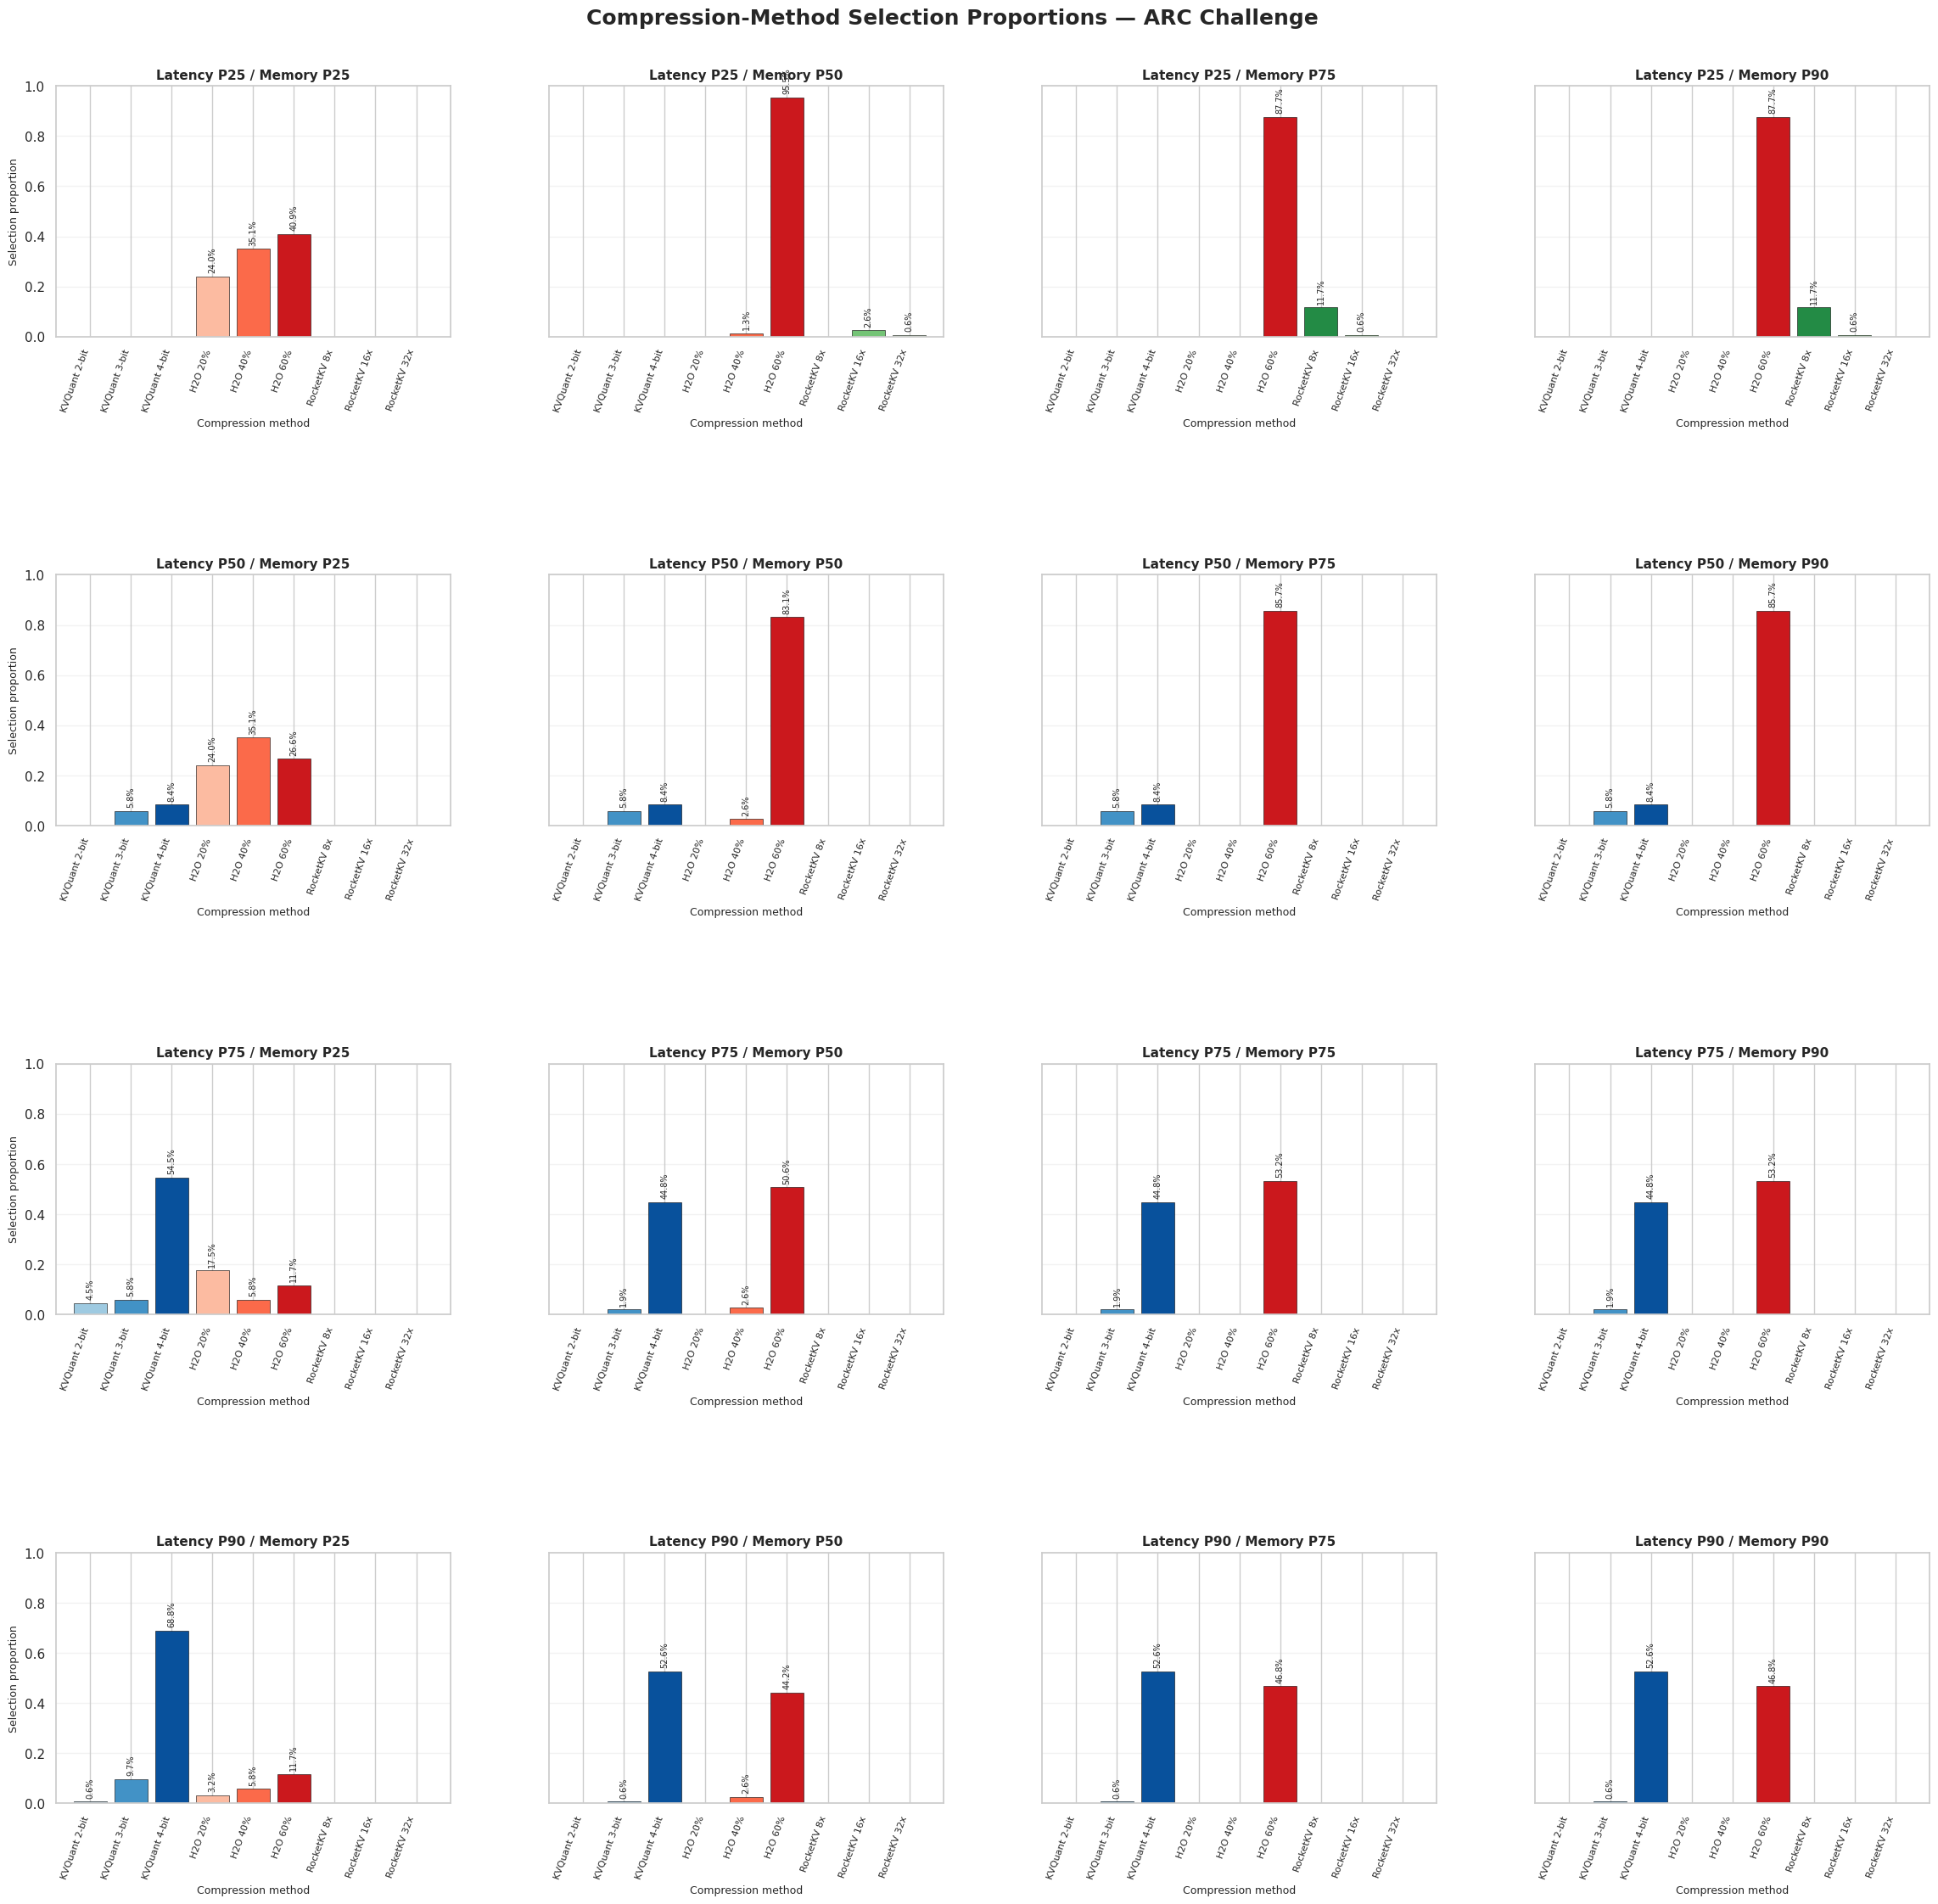

Saved: /content/drive/MyDrive/KV_Cache_Models/adaptive_evaluation/dataset_selection_graphs/selection_proportions_arc_challenge.png


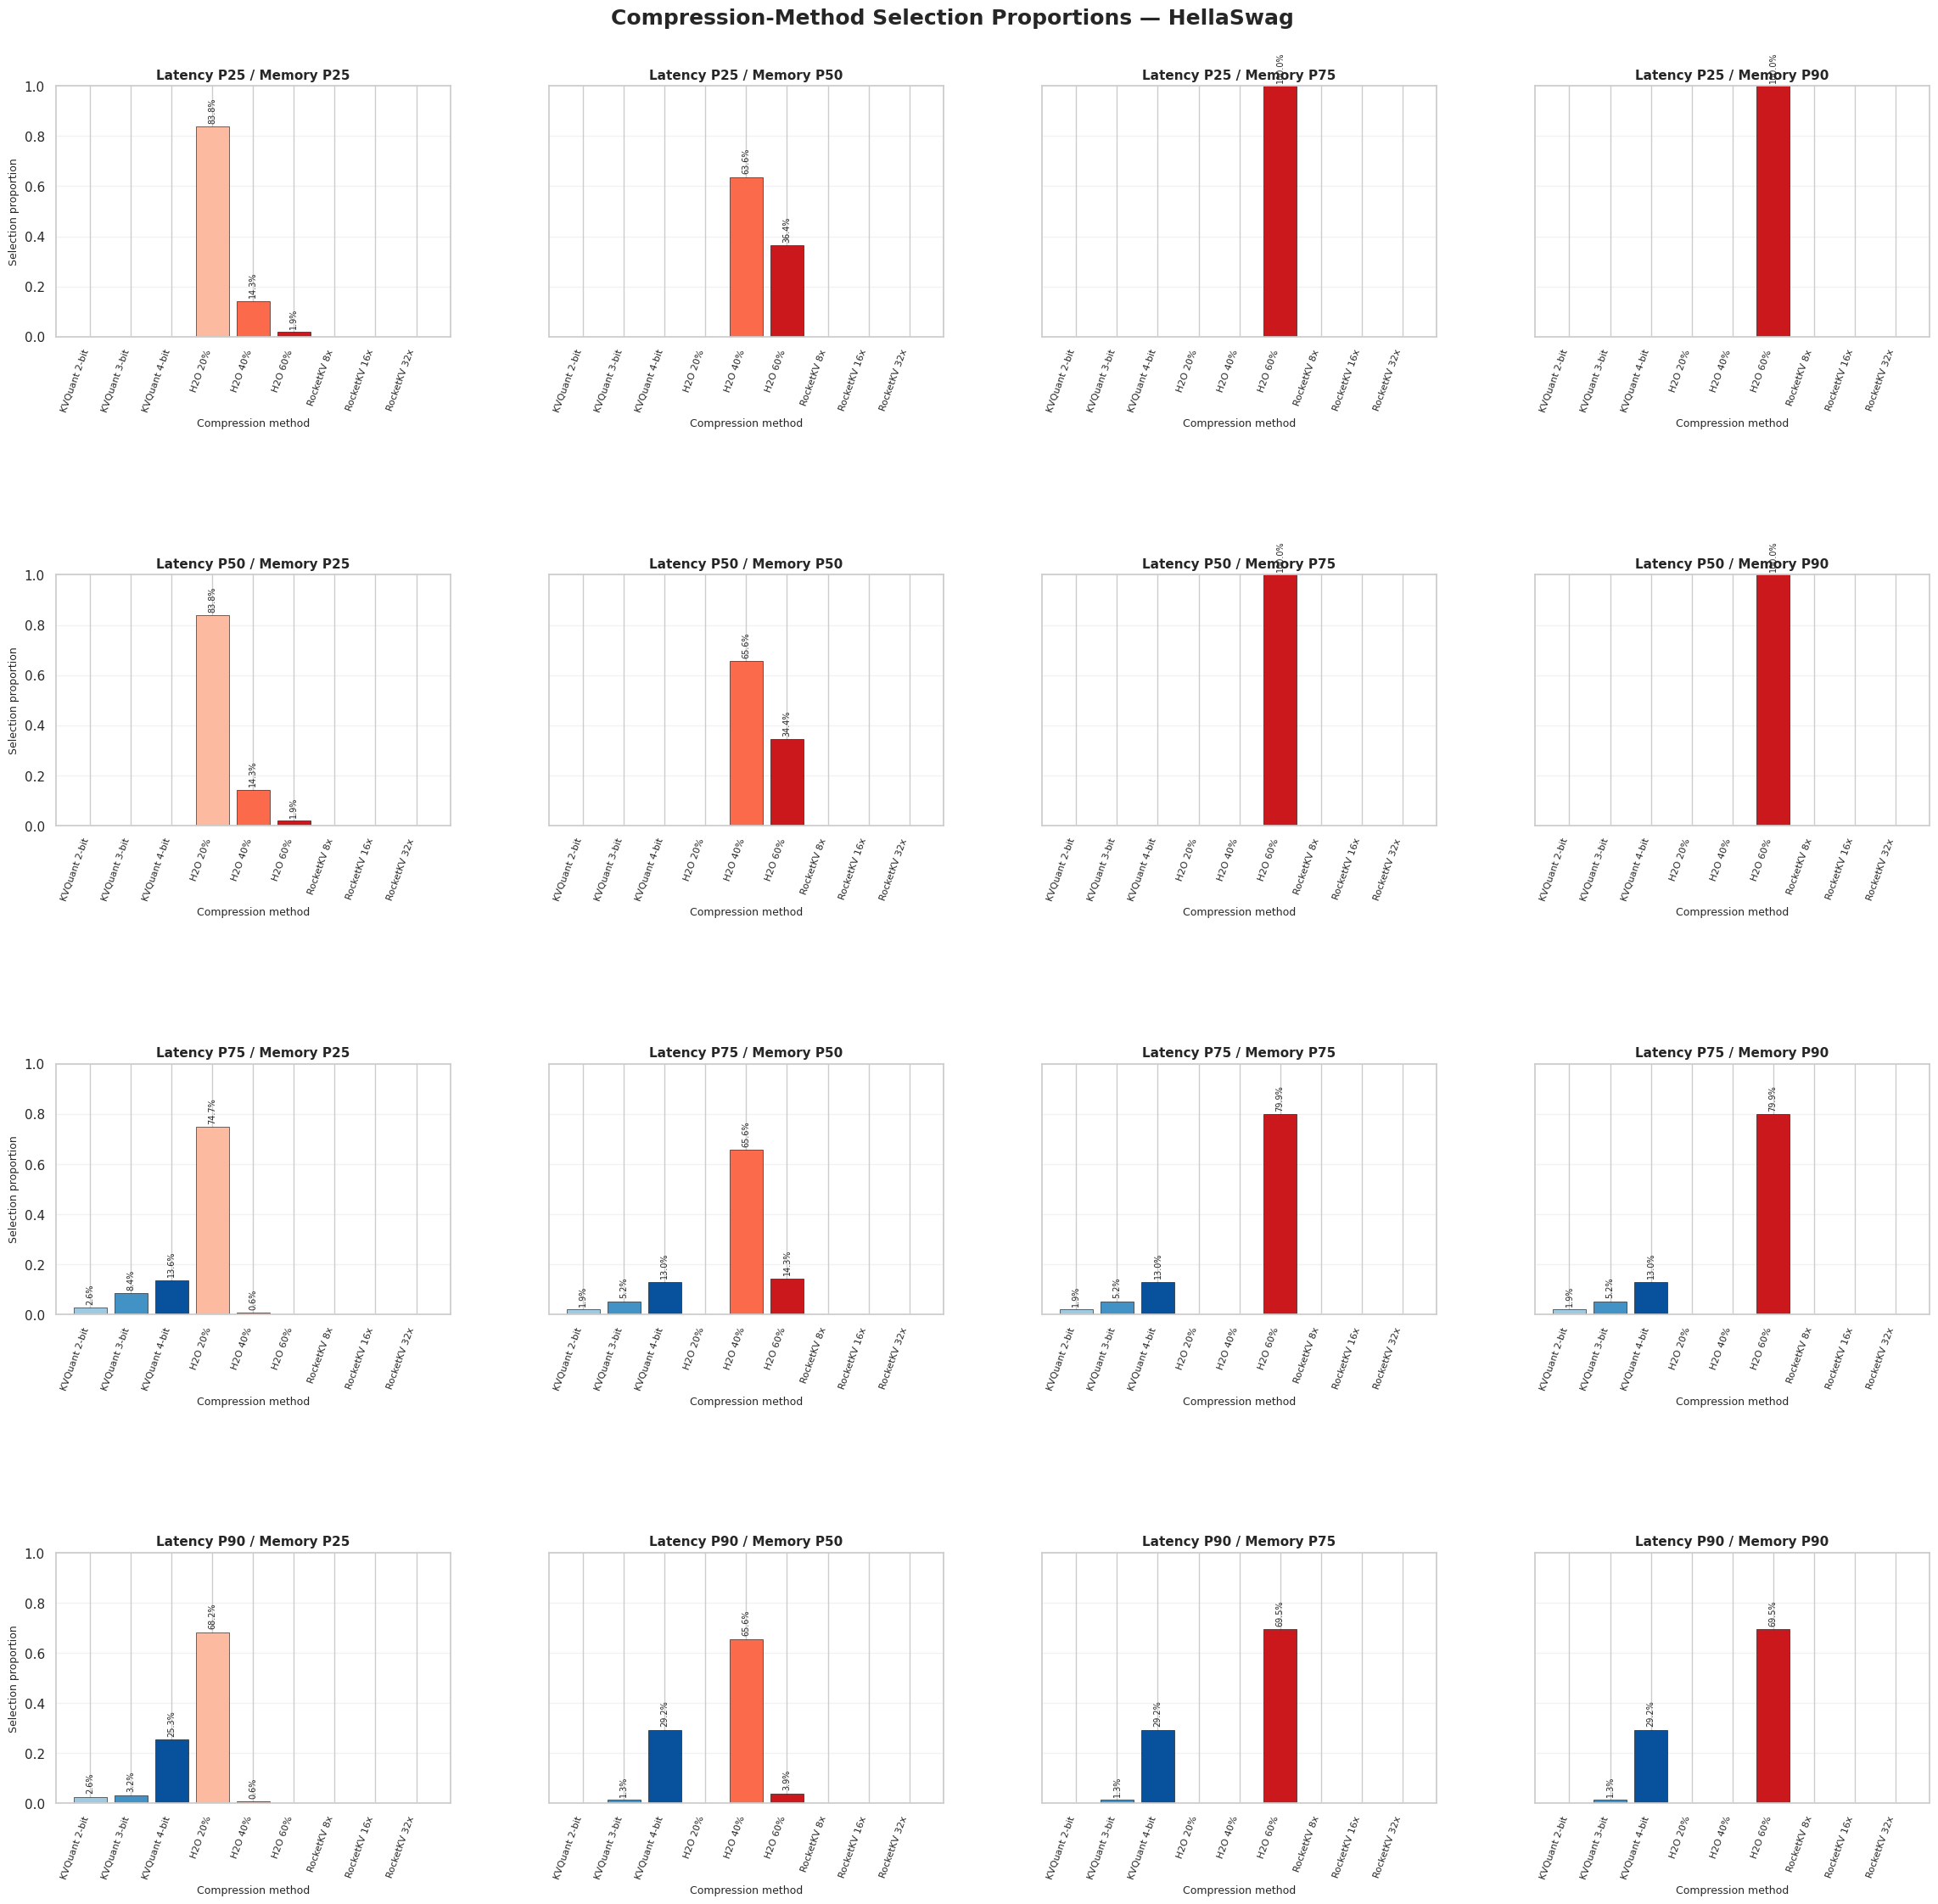

Saved: /content/drive/MyDrive/KV_Cache_Models/adaptive_evaluation/dataset_selection_graphs/selection_proportions_hellaswag.png

All images and exact selection proportions were saved to: /content/drive/MyDrive/KV_Cache_Models/adaptive_evaluation/dataset_selection_graphs


In [ ]:
# ============================================================================
# SELECTION PROPORTIONS BY DATASET
# Creates one separate image for GSM8K, ARC Challenge, and HellaSwag.
# Every subplot displays its own compression-method x-axis labels.
# ============================================================================

dataset_selection_dir = OUTPUT_DIR / "dataset_selection_graphs"
dataset_selection_dir.mkdir(parents=True, exist_ok=True)

method_colors = {
    "kvquant_2bit": "#9ECAE1",
    "kvquant_3bit": "#4292C6",
    "kvquant_4bit": "#08519C",
    "h2o_20": "#FCBBA1",
    "h2o_40": "#FB6A4A",
    "h2o_60": "#CB181D",
    "rocketkv_8x": "#238B45",
    "rocketkv_16x": "#74C476",
    "rocketkv_32x": "#C7E9C0",
}

method_labels = {
    "kvquant_2bit": "KVQuant 2-bit",
    "kvquant_3bit": "KVQuant 3-bit",
    "kvquant_4bit": "KVQuant 4-bit",
    "h2o_20": "H2O 20%",
    "h2o_40": "H2O 40%",
    "h2o_60": "H2O 60%",
    "rocketkv_8x": "RocketKV 8x",
    "rocketkv_16x": "RocketKV 16x",
    "rocketkv_32x": "RocketKV 32x",
}

selection_summary_by_dataset = []

for dataset in DATASETS:
    dataset_results = adaptive_results[
        adaptive_results["dataset"] == dataset
    ]

    fig, axes = plt.subplots(
        4,
        4,
        figsize=(24, 23),
        sharex=False,
        sharey=True,
    )

    for row_index, latency_pct in enumerate(PERCENTILES):
        for column_index, memory_pct in enumerate(PERCENTILES):
            axis = axes[row_index, column_index]

            combination_results = dataset_results[
                (dataset_results["latency_percentile"] == latency_pct)
                & (dataset_results["memory_percentile"] == memory_pct)
            ]

            proportions = (
                combination_results["selected_method"]
                .value_counts(normalize=True)
                .reindex(CONFIGS, fill_value=0)
            )

            counts = (
                combination_results["selected_method"]
                .value_counts()
                .reindex(CONFIGS, fill_value=0)
            )

            bars = axis.bar(
                range(len(CONFIGS)),
                proportions.values,
                color=[
                    method_colors[method]
                    for method in CONFIGS
                ],
                edgecolor="black",
                linewidth=0.4,
            )

            axis.set_title(
                f"Latency P{latency_pct} / Memory P{memory_pct}",
                fontsize=11,
                fontweight="bold",
            )

            axis.set_ylim(0, 1)
            axis.set_xticks(range(len(CONFIGS)))

            axis.set_xticklabels(
                [
                    method_labels[method]
                    for method in CONFIGS
                ],
                rotation=70,
                ha="right",
                fontsize=8,
            )

            # Force x-axis labels to appear on every subplot
            axis.tick_params(
                axis="x",
                which="both",
                labelbottom=True,
            )

            axis.set_xlabel(
                "Compression method",
                fontsize=9,
            )

            if column_index == 0:
                axis.set_ylabel(
                    "Selection proportion",
                    fontsize=9,
                )

            axis.grid(
                axis="y",
                alpha=0.25,
            )

            # Display the selection percentage above every nonzero bar
            for bar, proportion in zip(
                bars,
                proportions.values,
            ):
                if proportion > 0:
                    axis.annotate(
                        f"{proportion:.1%}",
                        xy=(
                            bar.get_x()
                            + bar.get_width() / 2,
                            bar.get_height(),
                        ),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha="center",
                        va="bottom",
                        fontsize=7,
                        rotation=90,
                    )

            # Store the exact counts and proportions
            for method in CONFIGS:
                selection_summary_by_dataset.append(
                    {
                        "dataset": dataset,
                        "latency_percentile": latency_pct,
                        "memory_percentile": memory_pct,
                        "constraint_label": (
                            f"L{latency_pct}/M{memory_pct}"
                        ),
                        "compression_method": method,
                        "selection_count": int(
                            counts[method]
                        ),
                        "selection_proportion": float(
                            proportions[method]
                        ),
                    }
                )

    fig.suptitle(
        (
            "Compression-Method Selection Proportions — "
            f"{DATASET_TITLES[dataset]}"
        ),
        fontsize=18,
        fontweight="bold",
    )

    # Extra vertical spacing prevents x-axis labels from overlapping
    fig.subplots_adjust(
        top=0.94,
        bottom=0.06,
        left=0.06,
        right=0.98,
        hspace=0.95,
        wspace=0.25,
    )

    save_path = (
        dataset_selection_dir
        / f"selection_proportions_{dataset}.png"
    )

    plt.savefig(
        save_path,
        dpi=250,
        bbox_inches="tight",
        facecolor="white",
    )

    # Display each dataset as a separate image in Colab
    plt.show()

    print(f"Saved: {save_path}")

selection_summary_by_dataset = pd.DataFrame(
    selection_summary_by_dataset
)

selection_summary_by_dataset.to_csv(
    dataset_selection_dir
    / "dataset_selection_proportions.csv",
    index=False,
)

print(
    "\nAll images and exact selection proportions were saved to:",
    dataset_selection_dir,
)

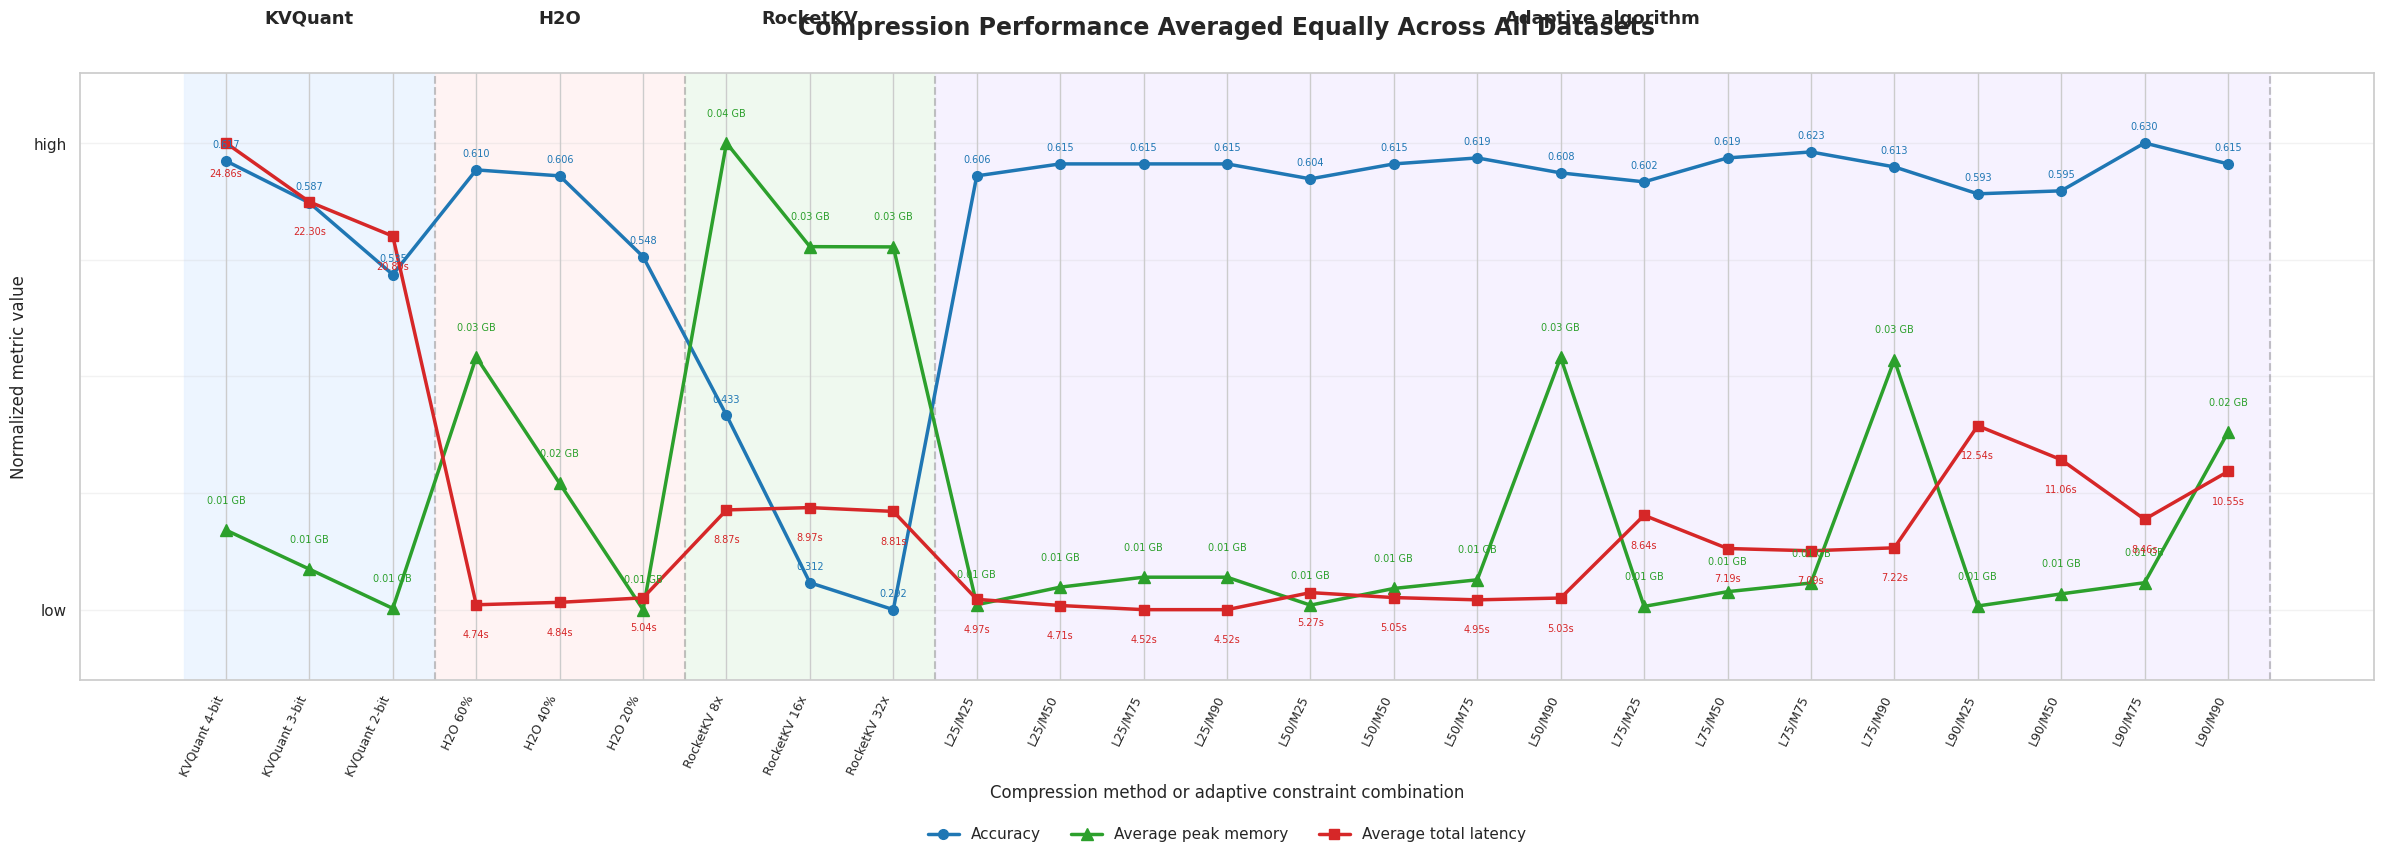

Saved: /content/drive/MyDrive/KV_Cache_Models/adaptive_evaluation/average_over_datasets_graphs/average_performance_all_datasets.png


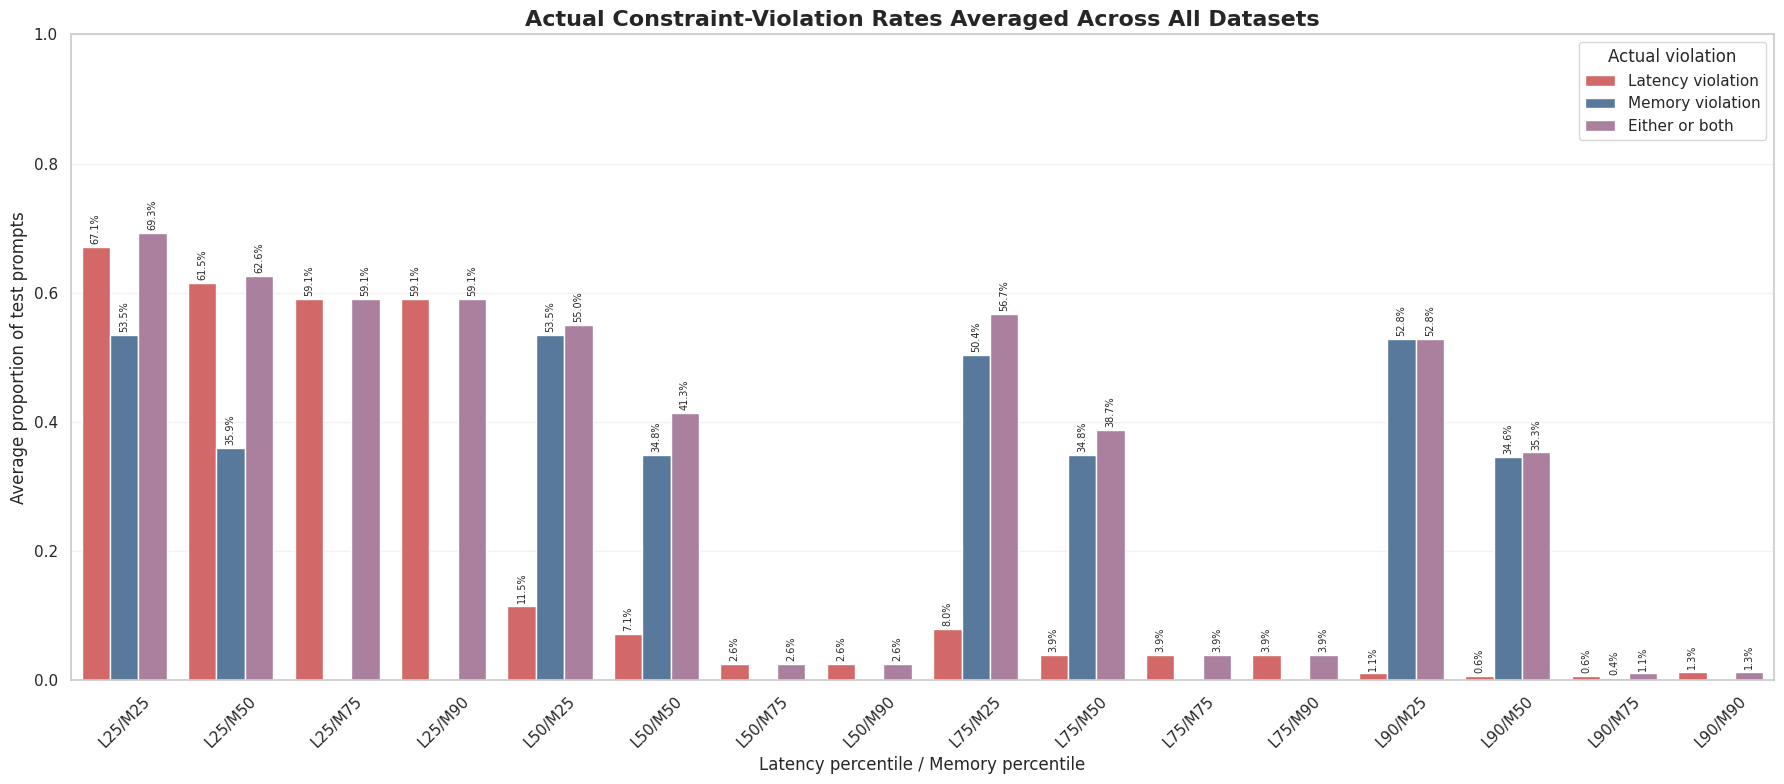

Saved: /content/drive/MyDrive/KV_Cache_Models/adaptive_evaluation/average_over_datasets_graphs/average_constraint_violations_all_datasets.png


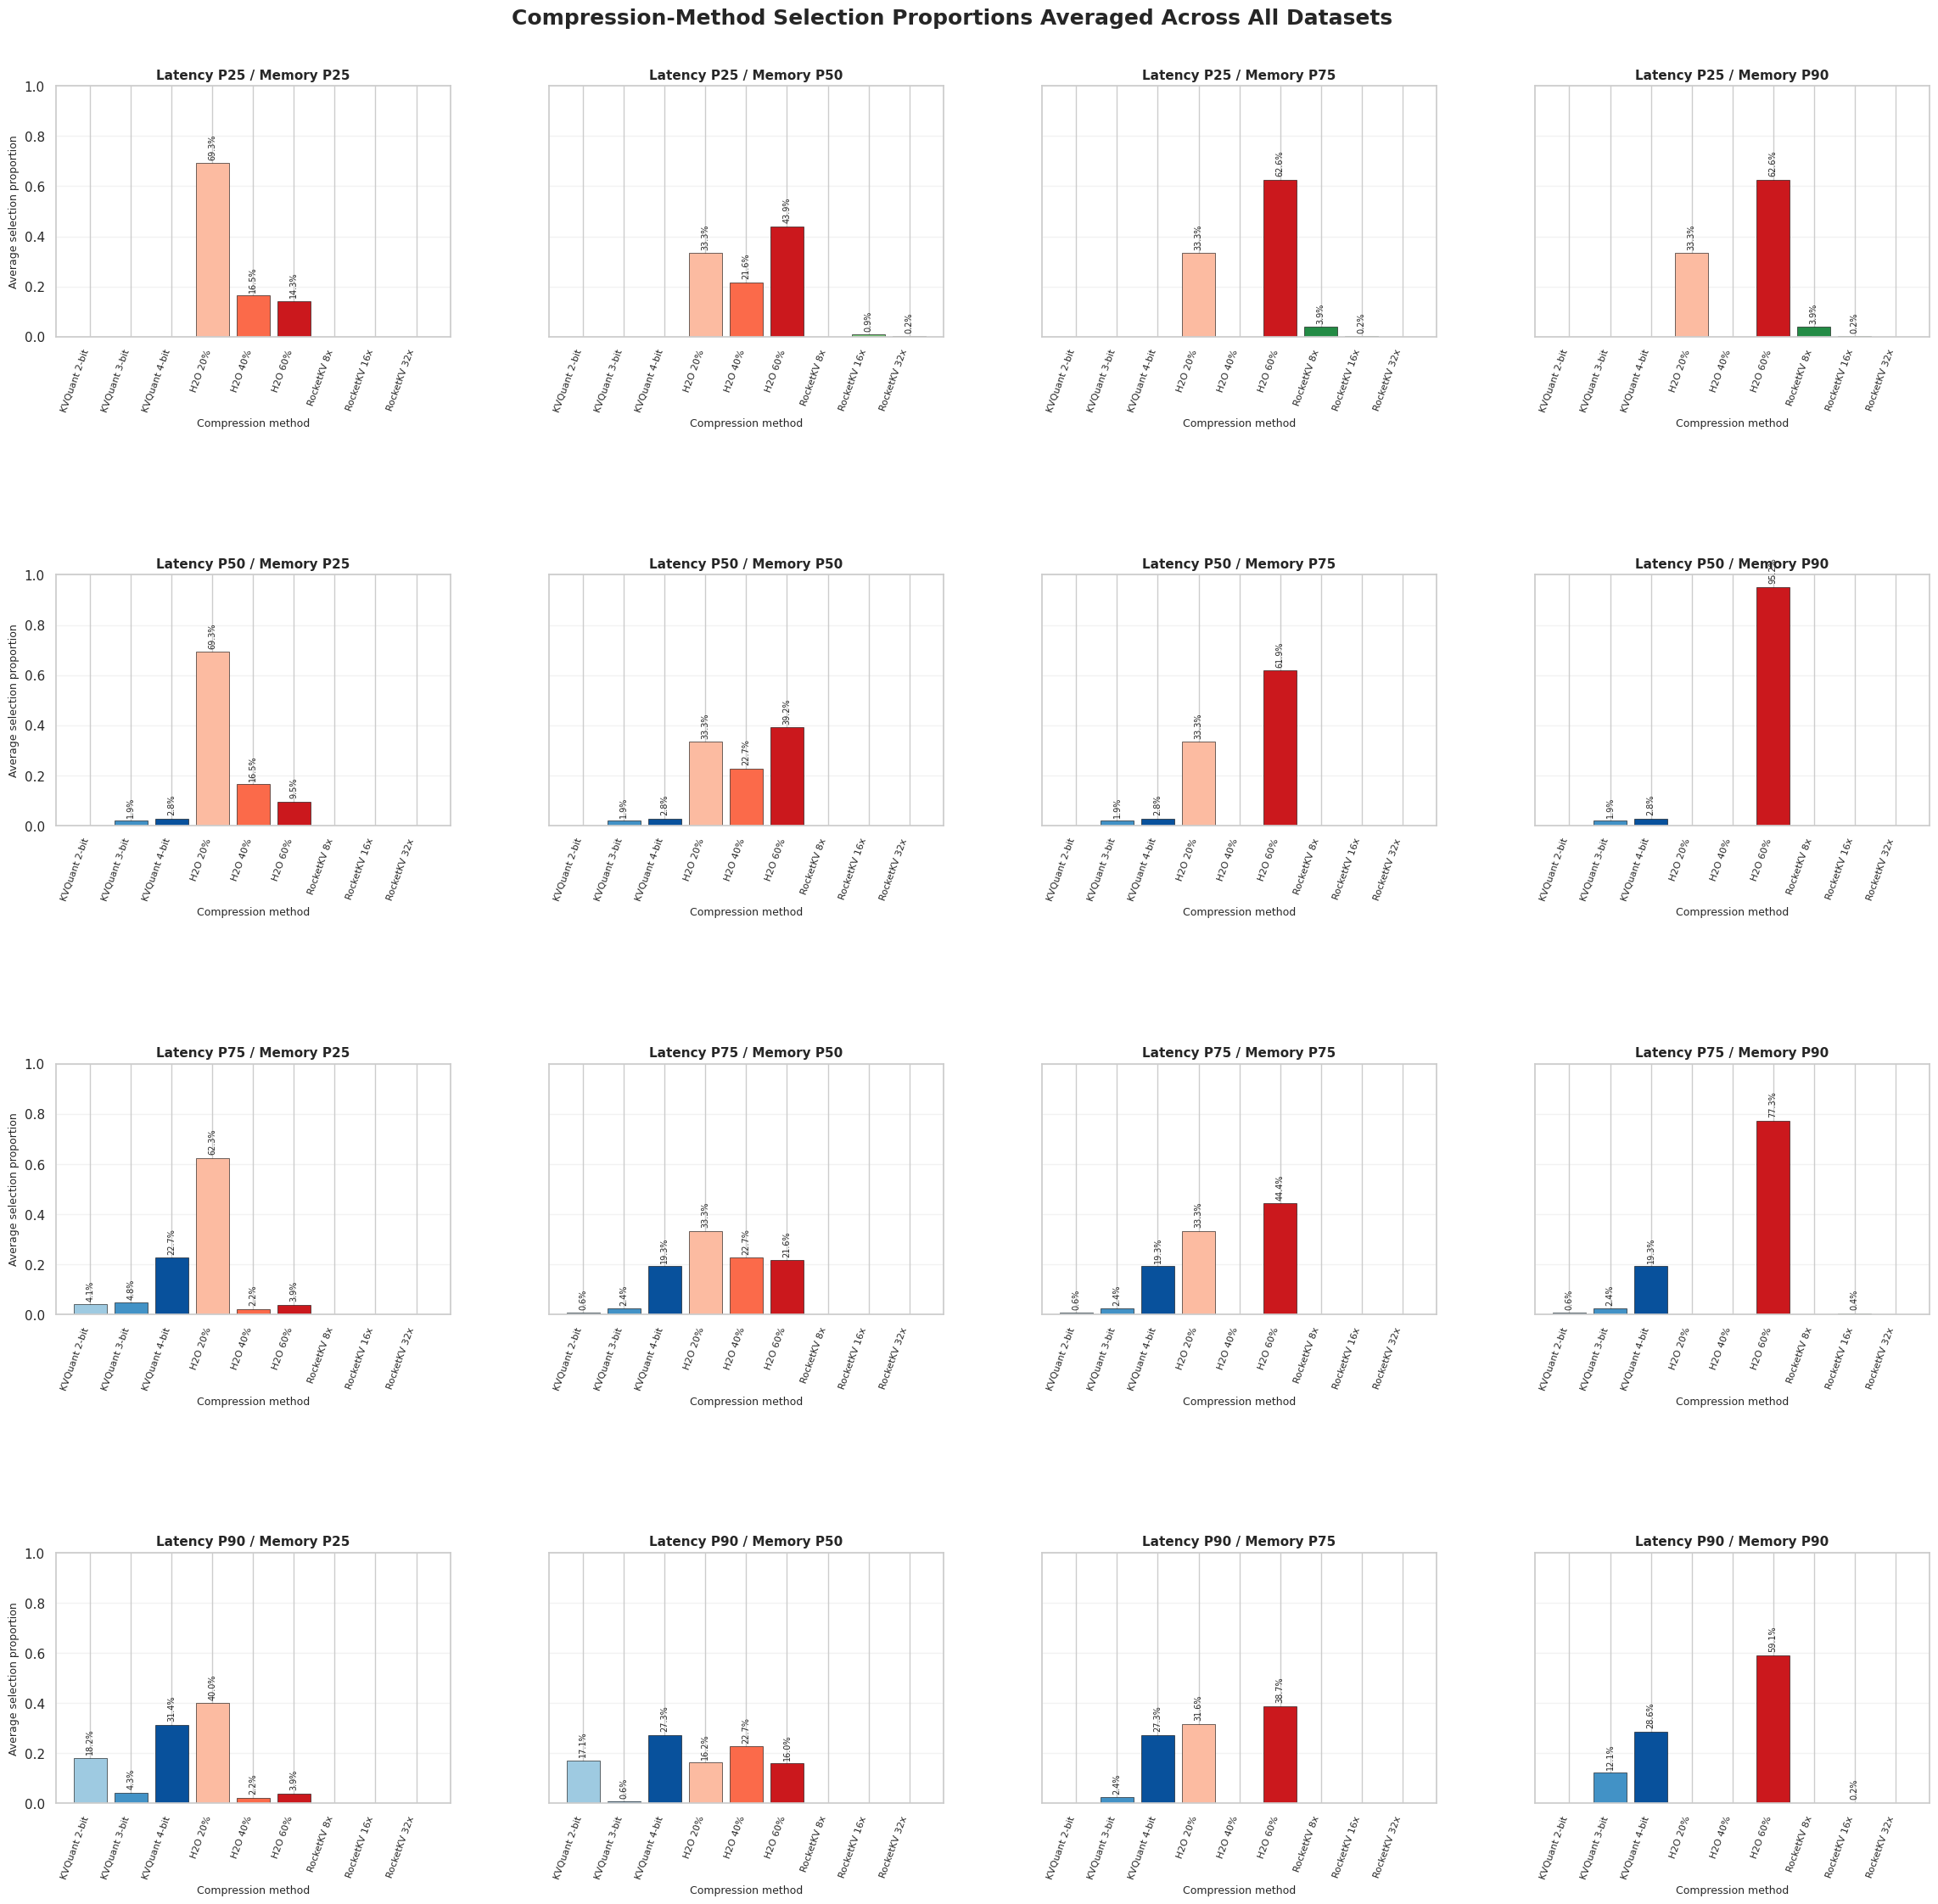

Saved: /content/drive/MyDrive/KV_Cache_Models/adaptive_evaluation/average_over_datasets_graphs/average_selection_proportions_all_datasets.png

All average-over-datasets graphs and CSV files were saved to: /content/drive/MyDrive/KV_Cache_Models/adaptive_evaluation/average_over_datasets_graphs


In [ ]:
# ============================================================================
# AVERAGE-OVER-DATASETS GRAPHS
#
# Produces three separate images:
# 1. Accuracy, memory, and latency averaged equally across the three datasets
# 2. Constraint-violation rates averaged equally across the three datasets
# 3. Compression-method selection proportions averaged equally across datasets
#
# Each dataset receives equal weight, regardless of its number of test prompts.
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

average_graph_dir = OUTPUT_DIR / "average_over_datasets_graphs"
average_graph_dir.mkdir(parents=True, exist_ok=True)

constraint_order = [
    f"L{latency_pct}/M{memory_pct}"
    for latency_pct in PERCENTILES
    for memory_pct in PERCENTILES
]

fixed_order = [
    "kvquant_4bit",
    "kvquant_3bit",
    "kvquant_2bit",
    "h2o_60",
    "h2o_40",
    "h2o_20",
    "rocketkv_8x",
    "rocketkv_16x",
    "rocketkv_32x",
]

strategy_order = fixed_order + constraint_order

method_labels = {
    "kvquant_2bit": "KVQuant 2-bit",
    "kvquant_3bit": "KVQuant 3-bit",
    "kvquant_4bit": "KVQuant 4-bit",
    "h2o_20": "H2O 20%",
    "h2o_40": "H2O 40%",
    "h2o_60": "H2O 60%",
    "rocketkv_8x": "RocketKV 8x",
    "rocketkv_16x": "RocketKV 16x",
    "rocketkv_32x": "RocketKV 32x",
}

method_colors = {
    "kvquant_2bit": "#9ECAE1",
    "kvquant_3bit": "#4292C6",
    "kvquant_4bit": "#08519C",
    "h2o_20": "#FCBBA1",
    "h2o_40": "#FB6A4A",
    "h2o_60": "#CB181D",
    "rocketkv_8x": "#238B45",
    "rocketkv_16x": "#74C476",
    "rocketkv_32x": "#C7E9C0",
}


def normalize_metric(values):
    """Min-max normalize values to the range [0, 1]."""
    values = np.asarray(values, dtype=float)
    minimum = values.min()
    maximum = values.max()

    if np.isclose(minimum, maximum):
        return np.full_like(values, 0.5)

    return (values - minimum) / (maximum - minimum)


def add_actual_labels(
    axis,
    x_values,
    normalized_values,
    actual_values,
    color,
    formatter,
    offset,
):
    for x, normalized, actual in zip(
        x_values,
        normalized_values,
        actual_values,
    ):
        axis.annotate(
            formatter(actual),
            xy=(x, normalized),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            va="bottom" if offset >= 0 else "top",
            fontsize=7,
            color=color,
        )


# ============================================================================
# GRAPH 1: AVERAGE ACCURACY, MEMORY, AND LATENCY
# ============================================================================

# performance_summary already has one result per dataset and strategy.
# Averaging these rows gives every dataset equal weight.
average_performance = (
    performance_summary.groupby(
        ["strategy", "strategy_type"],
        as_index=False,
    )
    .agg(
        accuracy=("accuracy", "mean"),
        average_memory_gb=("average_memory_gb", "mean"),
        average_latency_sec=("average_latency_sec", "mean"),
    )
)

average_performance["strategy"] = pd.Categorical(
    average_performance["strategy"],
    categories=strategy_order,
    ordered=True,
)

average_performance = (
    average_performance.dropna(subset=["strategy"])
    .sort_values("strategy")
    .reset_index(drop=True)
)

average_performance["strategy"] = (
    average_performance["strategy"].astype(str)
)

average_performance.to_csv(
    average_graph_dir / "average_performance.csv",
    index=False,
)

x = np.arange(len(average_performance))

actual_accuracy = average_performance["accuracy"].to_numpy()
actual_memory = average_performance["average_memory_gb"].to_numpy() * 1024  # GB -> MB for display
actual_latency = average_performance["average_latency_sec"].to_numpy()

normalized_accuracy = normalize_metric(actual_accuracy)
normalized_memory = normalize_metric(actual_memory)
normalized_latency = normalize_metric(actual_latency)

fig, axis = plt.subplots(figsize=(24, 9))

background_regions = [
    (-0.5, 2.5, "#E8F2FF", "KVQuant"),
    (2.5, 5.5, "#FFF0F0", "H2O"),
    (5.5, 8.5, "#EAF8EA", "RocketKV"),
    (
        8.5,
        len(average_performance) - 0.5,
        "#F3EEFF",
        "Adaptive algorithm",
    ),
]

for start, end, color, label in background_regions:
    axis.axvspan(
        start,
        end,
        color=color,
        alpha=0.75,
        zorder=0,
    )

    axis.axvline(
        end,
        color="gray",
        linestyle="--",
        alpha=0.45,
    )

    axis.text(
        (start + end) / 2,
        1.075,
        label,
        transform=axis.get_xaxis_transform(),
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
    )

axis.plot(
    x,
    normalized_accuracy,
    color="#1F77B4",
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Accuracy",
)

axis.plot(
    x,
    normalized_memory,
    color="#2CA02C",
    marker="^",
    linewidth=2.5,
    markersize=8,
    label="Average peak memory",
)

axis.plot(
    x,
    normalized_latency,
    color="#D62728",
    marker="s",
    linewidth=2.5,
    markersize=7,
    label="Average total latency",
)

add_actual_labels(
    axis,
    x,
    normalized_accuracy,
    actual_accuracy,
    "#1F77B4",
    lambda value: f"{value:.3f}",
    8,
)

add_actual_labels(
    axis,
    x,
    normalized_memory,
    actual_memory,
    "#2CA02C",
    lambda value: f"{value:.3f} MB",
    18,
)

add_actual_labels(
    axis,
    x,
    normalized_latency,
    actual_latency,
    "#D62728",
    lambda value: f"{value:.2f}s",
    -18,
)

performance_labels = [
    method_labels.get(strategy, strategy)
    for strategy in average_performance["strategy"]
]

axis.set_xticks(x)
axis.set_xticklabels(
    performance_labels,
    rotation=65,
    ha="right",
    fontsize=9,
)

axis.set_ylim(-0.15, 1.15)
axis.set_yticks([0, 0.25, 0.50, 0.75, 1.0])
axis.set_yticklabels(["low", "", "", "", "high"])

axis.set_xlabel(
    "Compression method or adaptive constraint combination"
)
axis.set_ylabel("Normalized metric value")

axis.set_title(
    "Compression Performance Averaged Equally Across All Datasets",
    fontsize=17,
    fontweight="bold",
    pad=28,
)

axis.grid(axis="y", alpha=0.25)

axis.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    frameon=False,
    fontsize=11,
)

plt.tight_layout()

performance_path = (
    average_graph_dir
    / "average_performance_all_datasets.png"
)

plt.savefig(
    performance_path,
    dpi=250,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
print(f"Saved: {performance_path}")


# ============================================================================
# GRAPH 2: AVERAGE CONSTRAINT-VIOLATION RATES
# ============================================================================

# First calculate rates independently for each dataset.
per_dataset_violations = (
    adaptive_results.groupby(
        [
            "dataset",
            "latency_percentile",
            "memory_percentile",
            "constraint_label",
        ],
        as_index=False,
        sort=False,
    )
    .agg(
        latency_violation_rate=("latency_violation", "mean"),
        memory_violation_rate=("memory_violation", "mean"),
        any_violation_rate=("any_violation", "mean"),
        fallback_rate=("used_fallback", "mean"),
    )
)

# Then average those rates so every dataset has equal weight.
average_violations = (
    per_dataset_violations.groupby(
        [
            "latency_percentile",
            "memory_percentile",
            "constraint_label",
        ],
        as_index=False,
        sort=False,
    )
    .agg(
        latency_violation_rate=(
            "latency_violation_rate",
            "mean",
        ),
        memory_violation_rate=(
            "memory_violation_rate",
            "mean",
        ),
        any_violation_rate=(
            "any_violation_rate",
            "mean",
        ),
        fallback_rate=(
            "fallback_rate",
            "mean",
        ),
    )
)

average_violations["constraint_label"] = pd.Categorical(
    average_violations["constraint_label"],
    categories=constraint_order,
    ordered=True,
)

average_violations = average_violations.sort_values(
    "constraint_label"
)

average_violations.to_csv(
    average_graph_dir / "average_constraint_violations.csv",
    index=False,
)

average_violation_long = average_violations.melt(
    id_vars=[
        "constraint_label",
        "latency_percentile",
        "memory_percentile",
    ],
    value_vars=[
        "latency_violation_rate",
        "memory_violation_rate",
        "any_violation_rate",
    ],
    var_name="violation_type",
    value_name="proportion",
)

average_violation_long["violation_type"] = (
    average_violation_long["violation_type"].map(
        {
            "latency_violation_rate": "Latency violation",
            "memory_violation_rate": "Memory violation",
            "any_violation_rate": "Either or both",
        }
    )
)

average_violation_long["constraint_label"] = pd.Categorical(
    average_violation_long["constraint_label"],
    categories=constraint_order,
    ordered=True,
)

average_violation_long = average_violation_long.sort_values(
    "constraint_label"
)

fig, axis = plt.subplots(figsize=(18, 8))

sns.barplot(
    data=average_violation_long,
    x="constraint_label",
    y="proportion",
    hue="violation_type",
    order=constraint_order,
    hue_order=[
        "Latency violation",
        "Memory violation",
        "Either or both",
    ],
    palette={
        "Latency violation": "#E45756",
        "Memory violation": "#4C78A8",
        "Either or both": "#B279A2",
    },
    ax=axis,
)

axis.set_ylim(0, 1)
axis.set_xlabel("Latency percentile / Memory percentile")
axis.set_ylabel("Average proportion of test prompts")

axis.set_title(
    "Actual Constraint-Violation Rates Averaged Across All Datasets",
    fontsize=16,
    fontweight="bold",
)

axis.tick_params(axis="x", rotation=45)
axis.legend(title="Actual violation", loc="upper right")
axis.grid(axis="y", alpha=0.25)

for container in axis.containers:
    axis.bar_label(
        container,
        labels=[
            f"{bar.get_height():.1%}"
            if bar.get_height() > 0
            else ""
            for bar in container
        ],
        padding=2,
        fontsize=7,
        rotation=90,
    )

plt.tight_layout()

violation_path = (
    average_graph_dir
    / "average_constraint_violations_all_datasets.png"
)

plt.savefig(
    violation_path,
    dpi=250,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
print(f"Saved: {violation_path}")


# ============================================================================
# GRAPH 3: AVERAGE COMPRESSION-METHOD SELECTION PROPORTIONS
# ============================================================================

# Count selections independently within each dataset and constraint pair.
per_dataset_selection = (
    adaptive_results.groupby(
        [
            "dataset",
            "latency_percentile",
            "memory_percentile",
            "constraint_label",
            "selected_method",
        ]
    )
    .size()
    .rename("selection_count")
    .reset_index()
)

per_dataset_totals = (
    adaptive_results.groupby(
        [
            "dataset",
            "latency_percentile",
            "memory_percentile",
            "constraint_label",
        ]
    )
    .size()
    .rename("total_prompts")
    .reset_index()
)

per_dataset_selection = per_dataset_selection.merge(
    per_dataset_totals,
    on=[
        "dataset",
        "latency_percentile",
        "memory_percentile",
        "constraint_label",
    ],
    how="left",
)

per_dataset_selection["selection_proportion"] = (
    per_dataset_selection["selection_count"]
    / per_dataset_selection["total_prompts"]
)

# Create missing zero-selection rows so methods that were never selected
# are still included in the dataset average.
complete_rows = []

for dataset in DATASETS:
    for latency_pct in PERCENTILES:
        for memory_pct in PERCENTILES:
            label = f"L{latency_pct}/M{memory_pct}"

            current = per_dataset_selection[
                (per_dataset_selection["dataset"] == dataset)
                & (
                    per_dataset_selection["latency_percentile"]
                    == latency_pct
                )
                & (
                    per_dataset_selection["memory_percentile"]
                    == memory_pct
                )
            ]

            proportion_lookup = dict(
                zip(
                    current["selected_method"],
                    current["selection_proportion"],
                )
            )

            for method in CONFIGS:
                complete_rows.append(
                    {
                        "dataset": dataset,
                        "latency_percentile": latency_pct,
                        "memory_percentile": memory_pct,
                        "constraint_label": label,
                        "selected_method": method,
                        "selection_proportion": (
                            proportion_lookup.get(method, 0.0)
                        ),
                    }
                )

complete_selection = pd.DataFrame(complete_rows)

average_selection = (
    complete_selection.groupby(
        [
            "latency_percentile",
            "memory_percentile",
            "constraint_label",
            "selected_method",
        ],
        as_index=False,
    )
    .agg(
        selection_proportion=(
            "selection_proportion",
            "mean",
        )
    )
)

average_selection.to_csv(
    average_graph_dir / "average_selection_proportions.csv",
    index=False,
)

fig, axes = plt.subplots(
    4,
    4,
    figsize=(24, 23),
    sharex=False,
    sharey=True,
)

for row_index, latency_pct in enumerate(PERCENTILES):
    for column_index, memory_pct in enumerate(PERCENTILES):
        axis = axes[row_index, column_index]

        combination = average_selection[
            (
                average_selection["latency_percentile"]
                == latency_pct
            )
            & (
                average_selection["memory_percentile"]
                == memory_pct
            )
        ]

        proportions = (
            combination.set_index("selected_method")[
                "selection_proportion"
            ]
            .reindex(CONFIGS, fill_value=0)
        )

        bars = axis.bar(
            range(len(CONFIGS)),
            proportions.values,
            color=[
                method_colors[method]
                for method in CONFIGS
            ],
            edgecolor="black",
            linewidth=0.4,
        )

        axis.set_title(
            f"Latency P{latency_pct} / Memory P{memory_pct}",
            fontsize=11,
            fontweight="bold",
        )

        axis.set_ylim(0, 1)
        axis.set_xticks(range(len(CONFIGS)))

        axis.set_xticklabels(
            [
                method_labels[method]
                for method in CONFIGS
            ],
            rotation=70,
            ha="right",
            fontsize=8,
        )

        axis.tick_params(
            axis="x",
            which="both",
            labelbottom=True,
        )

        axis.set_xlabel(
            "Compression method",
            fontsize=9,
        )

        if column_index == 0:
            axis.set_ylabel(
                "Average selection proportion",
                fontsize=9,
            )

        axis.grid(axis="y", alpha=0.25)

        for bar, proportion in zip(
            bars,
            proportions.values,
        ):
            if proportion > 0:
                axis.annotate(
                    f"{proportion:.1%}",
                    xy=(
                        bar.get_x()
                        + bar.get_width() / 2,
                        bar.get_height(),
                    ),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                    rotation=90,
                )

fig.suptitle(
    "Compression-Method Selection Proportions "
    "Averaged Across All Datasets",
    fontsize=18,
    fontweight="bold",
)

fig.subplots_adjust(
    top=0.94,
    bottom=0.06,
    left=0.06,
    right=0.98,
    hspace=0.95,
    wspace=0.25,
)

selection_path = (
    average_graph_dir
    / "average_selection_proportions_all_datasets.png"
)

plt.savefig(
    selection_path,
    dpi=250,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
print(f"Saved: {selection_path}")


print(
    "\nAll average-over-datasets graphs and CSV files were saved to:",
    average_graph_dir,
)